In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wyświetlania
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


 1. Struktura danych
 Czy dane zostały poprawnie wczytane (sprawdzenie .head() i .info())?
 Ile jest kolumn i wierszy?
 Jakie są typy danych (int, float, object, datetime)?

In [2]:

# Wczytanie danych z beneficiary
train_provider = pd.read_csv('Train-1542865627584.csv')

# sprawdzenie head
train_provider.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [3]:
# sprawdzenie info
train_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB


Widać że PotentialFraud ma wartości tylko Yes/No to flaga klasyfikacji ("Yes" / "No"), więc idealnie powinna być bool lub category.

In [4]:
# Konwersja na flagę binarną
train_provider['FraudFlag'] = train_provider['PotentialFraud'].map({'Yes': 1, 'No': 0})

# Sprawdź typy
print(train_provider.dtypes)

Provider          object
PotentialFraud    object
FraudFlag          int64
dtype: object


In [5]:
train_provider['PotentialFraud'] = train_provider['PotentialFraud'].astype('category')
train_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB


In [6]:
train_provider.shape

(5410, 3)

In [7]:
rows, cols = train_provider.shape
print(f"Liczba wierszy: {rows}")
print(f"Liczba kolumn: {cols}")

Liczba wierszy: 5410
Liczba kolumn: 3


In [8]:
# Wczytanie danych z beneficiary
train_beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')

# sprawdzenie head
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [9]:
train_beneficiary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

In [10]:
#DOB i DOD powinny być datetime

In [11]:
train_beneficiary.shape

(138556, 25)

In [12]:
train_beneficiary['RenalDiseaseIndicator'].value_counts()

RenalDiseaseIndicator
0    118978
Y     19578
Name: count, dtype: int64

In [13]:
#renalDiseaseIndicator albo nie mamy danych wtedy 0 albo jest ktoś chory

Ile osób  > 65 ma renalDiseaseIdicator

In [14]:
#Ile osób  > 65 ma renalDiseaseIndicator na true

# Zamiana DOB na datetime
train_beneficiary['DOB'] = pd.to_datetime(train_beneficiary['DOB'], errors='coerce')

# Data odniesienia: koniec 2009 roku
reference_date = pd.to_datetime('2009-12-31')

# Obliczenie wieku
train_beneficiary['Age'] = ((reference_date - train_beneficiary['DOB']).dt.days // 365)

# 🧮 Licznik: osoby > 65 z chorobą nerek
renal_over_65 = train_beneficiary[
    (train_beneficiary['Age'] > 65) &
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y')
]

# 🧮 Mianownik: wszystkie osoby > 65 lat
over_65 = train_beneficiary[train_beneficiary['Age'] > 65]

# ✅ Wyniki
print("Liczba osób >65 z chorobą nerek:", len(renal_over_65))
print("Liczba wszystkich osób >65:", len(over_65))

# 🔢 Procent:
percent = len(renal_over_65) / len(over_65) * 100
print(f"Procent osób > 65 z chorobą nerek: {percent:.2f}%")

Liczba osób >65 z chorobą nerek: 16219
Liczba wszystkich osób >65: 115881
Procent osób > 65 z chorobą nerek: 14.00%


In [15]:
#Ile osób poniżej < 65 ma renalDisease

# 🧮 Licznik: osoby < 65 z chorobą nerek
renal_under_65 = train_beneficiary[
    (train_beneficiary['Age'] < 65) &
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y')
]

# 🧮 Mianownik: wszystkie osoby < 65 lat
under_65 = train_beneficiary[train_beneficiary['Age'] < 65]

# ✅ Wyniki
print("Liczba osób < 65 z chorobą nerek:", len(renal_under_65))
print("Liczba wszystkich osób < 65:", len(under_65))

# 🔢 Procent:
percent_under = len(renal_under_65) / len(under_65) * 100
print(f"Procent osób < 65 z chorobą nerek: {percent_under:.2f}%")


Liczba osób < 65 z chorobą nerek: 3199
Liczba wszystkich osób < 65: 21607
Procent osób < 65 z chorobą nerek: 14.81%


In [16]:
#Czyli ok 14% ma wszystkich objetych ubezpieczeniem renalDisease

In [17]:
#Ile tych co ma renal disease ma chronicKidney

# Filtrowanie: osoby z chorobą nerek i z chroniczną chorobą nerek
renal_and_ckd = train_beneficiary[
    (train_beneficiary['RenalDiseaseIndicator'] == 'Y') &
    (train_beneficiary['ChronicCond_KidneyDisease'] == 1)
]

# Liczba osób z obiema cechami
print("Liczba osób z RenalDiseaseIndicator == 'Y' i ChronicKidney == 1:", len(renal_and_ckd))

# Wszystkie osoby z RenalDiseaseIndicator == 'Y'
renal_all = train_beneficiary[train_beneficiary['RenalDiseaseIndicator'] == 'Y']

# Procent tych, którzy mają również chronic kidney disease
percent_ckd = len(renal_and_ckd) / len(renal_all) * 100

print(f"Procent osób z chorobą nerek, które mają też chronic kidney disease: {percent_ckd:.2f}%")



Liczba osób z RenalDiseaseIndicator == 'Y' i ChronicKidney == 1: 15511
Procent osób z chorobą nerek, które mają też chronic kidney disease: 79.23%


In [18]:
# 79% tylko więc nie możemy zastąpić jedna kolumnę drugą chociaż widać zależności

In [19]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [20]:
# Jakie są wartości w NoOfMonths_PartACov

train_beneficiary['NoOfMonths_PartACov'].value_counts(normalize=True) * 100

NoOfMonths_PartACov
12    99.157741
0      0.721730
6      0.027426
11     0.020208
8      0.018765
10     0.012991
7      0.011548
4      0.009382
5      0.005774
9      0.005052
3      0.003609
2      0.003609
1      0.002165
Name: proportion, dtype: float64

In [21]:
# Jakie są wartości w NoOfMonths_PartACov

train_beneficiary['NoOfMonths_PartBCov'].value_counts(normalize=True) * 100

NoOfMonths_PartBCov
12    98.806259
0      0.487168
6      0.203528
10     0.108259
11     0.103207
9      0.088051
8      0.051243
7      0.045469
5      0.036086
4      0.025261
3      0.019487
2      0.013713
1      0.012269
Name: proportion, dtype: float64

In [22]:
train_beneficiary.head()


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [23]:
train_beneficiary['ChronicCond_Cancer'].value_counts()

ChronicCond_Cancer
2    121935
1     16621
Name: count, dtype: int64

In [24]:
#Ile procent benficjantów ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = train_beneficiary[train_beneficiary[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(train_beneficiary)) * 100
    
    results[col] = percent

# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą'])
df_results = df_results.sort_values(by='Procent osób z chorobą', ascending=False)

print(df_results)

                                 Procent osób z chorobą
ChronicCond_IschemicHeart                     67.585669
ChronicCond_Diabetes                          60.185773
ChronicCond_Heartfailure                      49.367765
ChronicCond_Depression                        35.552412
ChronicCond_Alzheimer                         33.218338
ChronicCond_KidneyDisease                     31.235746
ChronicCond_Osteoporasis                      27.468316
ChronicCond_rheumatoidarthritis               25.682035
ChronicCond_ObstrPulmonary                    23.715321
ChronicCond_Cancer                            11.995872
ChronicCond_stroke                             7.905829


In [25]:
#Ile procent benficjantów > 65 lat ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

older = train_beneficiary[train_beneficiary['Age'] > 65]
for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = older[older[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(older)) * 100
    
    results[col] = percent

# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą wśród osób starszych >65'])
df_results = df_results.sort_values(by='Procent osób z chorobą wśród osób starszych >65', ascending=False)

print(df_results)

                                 Procent osób z chorobą wśród osób starszych >65
ChronicCond_IschemicHeart                                              67.877391
ChronicCond_Diabetes                                                   60.286846
ChronicCond_Heartfailure                                               49.454181
ChronicCond_Depression                                                 34.514718
ChronicCond_Alzheimer                                                  33.014903
ChronicCond_KidneyDisease                                              31.144018
ChronicCond_Osteoporasis                                               27.734486
ChronicCond_rheumatoidarthritis                                        25.911927
ChronicCond_ObstrPulmonary                                             23.562965
ChronicCond_Cancer                                                     12.327301
ChronicCond_stroke                                                      7.950397


In [26]:
#Ile procent benficjantów <=65 ma daną chorobę np alzehemiera

# Lista kolumn z chorobami przewlekłymi
chronic_cols = [
    'ChronicCond_Alzheimer',
    'ChronicCond_Heartfailure',
    'ChronicCond_Cancer',
    'ChronicCond_Diabetes',
    'ChronicCond_KidneyDisease',
    'ChronicCond_Depression',
    'ChronicCond_stroke',
    'ChronicCond_ObstrPulmonary',
    'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis',
    'ChronicCond_rheumatoidarthritis',
]

results = {}

younger = train_beneficiary[train_beneficiary['Age'] <= 65]
younger_count = len(younger)
older = train_beneficiary[train_beneficiary['Age'] > 65]
older_count = len(older)
print(younger_count, older_count, len(train_beneficiary), older_count+younger_count)

results = {}

for col in chronic_cols:
    # Uwzględniamy tylko wiersze, gdzie nie ma wartości brakujących (czyli != 2)
    valid = younger[younger[col] != 2]
    
    # Liczymy procent osób z daną chorobą
    percent = (len(valid)/len(younger))*100
    
    results[col] = percent


# Zamiana na DataFrame dla czytelniejszego podsumowania
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Procent osób z chorobą wśród osób starszych <65'])
df_results = df_results.sort_values(by='Procent osób z chorobą wśród osób starszych <65', ascending=False)

print(df_results)



22675 115881 138556 138556
                                 Procent osób z chorobą wśród osób starszych <65
ChronicCond_IschemicHeart                                              66.094818
ChronicCond_Diabetes                                                   59.669239
ChronicCond_Heartfailure                                               48.926130
ChronicCond_Depression                                                 40.855568
ChronicCond_Alzheimer                                                  34.257993
ChronicCond_KidneyDisease                                              31.704520
ChronicCond_Osteoporasis                                               26.108049
ChronicCond_rheumatoidarthritis                                        24.507166
ChronicCond_ObstrPulmonary                                             24.493936
ChronicCond_Cancer                                                     10.302095
ChronicCond_stroke                                                      7.678060


In [27]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [28]:
train_beneficiary['IPAnnualReimbursementAmt'].value_counts(normalize=True) * 100


IPAnnualReimbursementAmt
0        73.985248
4000      1.532232
5000      1.335922
3000      1.299114
6000      1.146829
           ...    
8630      0.000722
58350     0.000722
52600     0.000722
17190     0.000722
6170      0.000722
Name: proportion, Length: 3004, dtype: float64

In [29]:
# To pokazuje że w 73%  Medicare za leczenie szpitalne w ciągu roku 0


Który state i county najczestszy fraud 
Jakie choroby się najcześciej razem pojawiają 
Jakie choroby pojawiają się najczesciej przy fraudzie

In [30]:
#Patrzymy na statystyki wypłat za leczenie szpitalne ale biorąc pod uwagę tylko tych którzy byli w szpitalu
ip_annual_reimb_over_0 = train_beneficiary[train_beneficiary['IPAnnualReimbursementAmt']>0]
ip_annual_reimb_over_0['IPAnnualReimbursementAmt'].describe()

count     36030.000000
mean      14076.496253
std       14334.295941
min          10.000000
25%        5000.000000
50%        9505.000000
75%       17000.000000
max      161470.000000
Name: IPAnnualReimbursementAmt, dtype: float64

In [31]:
train_beneficiary['IPAnnualReimbursementAmt'].describe()

count    138556.000000
mean       3660.346502
std        9568.621827
min       -8000.000000
25%           0.000000
50%           0.000000
75%        2280.000000
max      161470.000000
Name: IPAnnualReimbursementAmt, dtype: float64

In [32]:
# tutaj widać jakby były uwzglednieni pacjenci co 0 otrzymali - widać jak bardzo są zaburzone

In [33]:
# IPAnnualDeductibleAmt
# = Roczna kwota udziału własnego pacjenta (deductible) za leczenie szpitalne (Inpatient)

In [34]:
train_beneficiary['IPAnnualDeductibleAmt'].value_counts(normalize=True) * 100

IPAnnualDeductibleAmt
0        73.630157
1068     19.568261
2136      4.632062
3204      1.068882
4272      0.266318
           ...    
3234      0.000722
1118      0.000722
3904      0.000722
21204     0.000722
24068     0.000722
Name: proportion, Length: 147, dtype: float64

In [35]:
#Patrzymy na statystyki wypłat za leczenie szpitalne ale biorąc pod uwagę tylko tych którzy byli w szpitalu
ip_annual_deduct_over_0 = train_beneficiary[train_beneficiary['IPAnnualDeductibleAmt']>0]
ip_annual_deduct_over_0['IPAnnualDeductibleAmt'].describe()

count    36537.000000
mean      1516.305170
std       1332.006369
min       1068.000000
25%       1068.000000
50%       1068.000000
75%       2136.000000
max      38272.000000
Name: IPAnnualDeductibleAmt, dtype: float64

In [36]:
train_beneficiary['OPAnnualDeductibleAmt'].value_counts(normalize=True) * 100

OPAnnualDeductibleAmt
0        10.024828
20        5.247698
10        4.431421
30        3.431825
100       3.423165
           ...    
6610      0.000722
4090      0.000722
7930      0.000722
4320      0.000722
13040     0.000722
Name: proportion, Length: 789, dtype: float64

In [37]:
#Patrzymy na statystyki wypłat za leczenie ambulatoryjene ale biorąc pod uwagę tylko tych którzy wygenerowali koszty
opa_annual_deduct_over_0 = train_beneficiary[train_beneficiary['OPAnnualDeductibleAmt']>0]
opa_annual_deduct_over_0['OPAnnualDeductibleAmt'].describe()

count    124666.000000
mean        419.802761
std         667.436176
min          10.000000
25%          70.000000
50%         200.000000
75%         510.000000
max       13840.000000
Name: OPAnnualDeductibleAmt, dtype: float64

In [38]:
train_beneficiary['OPAnnualReimbursementAmt'].value_counts(normalize=True) * 100

OPAnnualReimbursementAmt
0        3.034874
100      2.826294
200      2.275614
60       1.944340
300      1.645544
           ...   
12130    0.000722
22470    0.000722
16030    0.000722
19390    0.000722
38650    0.000722
Name: proportion, Length: 2078, dtype: float64

In [39]:
#tutaj już tylko 3% nie korzysta z uslug ambulatoryjnych

In [40]:
#Patrzymy na statystyki wypłat za leczenie ambulatoryjene ale biorąc pod uwagę tylko tych którzy wygenerowali koszty
opa_annual_deduct_over_0 = train_beneficiary[train_beneficiary['OPAnnualReimbursementAmt']>0]
opa_annual_deduct_over_0['OPAnnualReimbursementAmt'].describe()

count    134339.000000
mean       1338.974832
std        2521.944636
min          10.000000
25%         200.000000
50%         600.000000
75%        1560.000000
max      102960.000000
Name: OPAnnualReimbursementAmt, dtype: float64

In [41]:
# Duzy rozdzwięk między min a max i pomiedzy średnią a 50% 


In [42]:
# Wczytanie danych z beneficiary
train_inpatientdata = pd.read_csv('Train_Inpatientdata-1542865627584.csv')


# sprawdzenie head
train_inpatientdata.head()



,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [43]:
train_inpatientdata.shape

(40474, 30)

In [44]:
train_inpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  ClmDiagnosisCode_1      40474 non-null

In [45]:
# widać że wszystkie daty  ClaimStartDt ClaimEndDt  AdmissionDt są object a nie daty

In [46]:
# Wczytanie danych z beneficiary
train_outpatientdata = pd.read_csv('Train_Outpatientdata-1542865627584.csv')


# sprawdzenie head
train_outpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [47]:
train_outpatientdata.shape

(517737, 27)

In [48]:
train_outpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517737 entries, 0 to 517736
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   BeneID                  517737 non-null  object 
 1   ClaimID                 517737 non-null  object 
 2   ClaimStartDt            517737 non-null  object 
 3   ClaimEndDt              517737 non-null  object 
 4   Provider                517737 non-null  object 
 5   InscClaimAmtReimbursed  517737 non-null  int64  
 6   AttendingPhysician      516341 non-null  object 
 7   OperatingPhysician      90617 non-null   object 
 8   OtherPhysician          195046 non-null  object 
 9   ClmDiagnosisCode_1      507284 non-null  object 
 10  ClmDiagnosisCode_2      322357 non-null  object 
 11  ClmDiagnosisCode_3      203257 non-null  object 
 12  ClmDiagnosisCode_4      125596 non-null  object 
 13  ClmDiagnosisCode_5      74344 non-null   object 
 14  ClmDiagnosisCode_6  

In [49]:
# znowu widać że wszystkie daty  ClaimStartDt ClaimEndDt  AdmissionDt są object a nie daty

In [50]:
# Czy w zbiorze występują brakujące wartości (NaN, null)?

train_provider.info()
train_beneficiary.info()
train_inpatientdata.info()
train_outpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           138556 non-null  object        
 1   DOB                              138556 non-null  datetime64[ns]
 2   DOD                              1421 non-null    object        
 3   Gender                           138556 non-null  int64         
 4   Race                             138556 non-null  int64         

In [51]:
#Wszystkie kolumny są oznaczone jako not-null, ale jak wynika z analizy u góry, niektóre z kolumn skrywają duzo danych brakujących lub NAN
# Sprawdzenie brakujących danych dla train_provider
print("Braki w train_provider:")
print(train_provider.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_beneficiary
print("Braki w train_beneficiary:")
print(train_beneficiary.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())
print("\n")

# Sprawdzenie brakujących danych dla train_outpatientdata
print("Braki w train_outpatientdata:")
print(train_outpatientdata.isnull().sum())
print("\n")



Braki w train_provider:
Provider          0
PotentialFraud    0
FraudFlag         0
dtype: int64


Braki w train_beneficiary:
BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                

In [52]:
train_beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50,73
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40,73
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760,87
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200,74


In [53]:
# W train_beneficiary jest tylko DOD date of death z NaN która mowi że nie ma wartości i jest to wiadomość że pacjent nie zmarl 
# ChronicCond_Alzheimer.... i wszystkie inne maja 2 dla oznaczenia że nie ma wartoci ktora tak naprawde jest NaN

In [54]:
train_inpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [55]:

# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())
print("\n")

Braki w train_inpatientdata:
BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int6

In [56]:
train_inpatientdata['AdmissionDt'] = pd.to_datetime(train_inpatientdata['AdmissionDt'], errors='coerce')
train_inpatientdata['DischargeDt'] = pd.to_datetime(train_inpatientdata['DischargeDt'], errors='coerce')
train_inpatientdata['ClaimStartDt'] = pd.to_datetime(train_inpatientdata['ClaimStartDt'], errors='coerce')
train_inpatientdata['ClaimEndDt'] = pd.to_datetime(train_inpatientdata['ClaimEndDt'], errors='coerce')

train_inpatientdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   BeneID                  40474 non-null  object        
 1   ClaimID                 40474 non-null  object        
 2   ClaimStartDt            40474 non-null  datetime64[ns]
 3   ClaimEndDt              40474 non-null  datetime64[ns]
 4   Provider                40474 non-null  object        
 5   InscClaimAmtReimbursed  40474 non-null  int64         
 6   AttendingPhysician      40362 non-null  object        
 7   OperatingPhysician      23830 non-null  object        
 8   OtherPhysician          4690 non-null   object        
 9   AdmissionDt             40474 non-null  datetime64[ns]
 10  ClmAdmitDiagnosisCode   40474 non-null  object        
 11  DeductibleAmtPaid       39575 non-null  float64       
 12  DischargeDt             40474 non-null  dateti

In [57]:
# Sprawdzenie brakujących danych dla train_inpatientdata
print("Braki w train_inpatientdata:")
print(train_inpatientdata.isnull().sum())

Braki w train_inpatientdata:
BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedureCode_6        40474
dtype: int6

In [58]:
train_inpatientdata.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [59]:
train_inpatientdata.shape

(40474, 30)

In [60]:
# Kolumny w train_inpatientdata bez żadnych braków (bez NaN)
non_nan_columns = train_inpatientdata.columns[train_inpatientdata.notnull().all()]
print("Kolumny bez NaN w train_inpatientdata:")
print(non_nan_columns)


Kolumny bez NaN w train_inpatientdata:
Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1'],
      dtype='object')


In [61]:
train_provider.head()


,Provider,PotentialFraud,FraudFlag
0,PRV51001,No,0
1,PRV51003,Yes,1
2,PRV51004,No,0
3,PRV51005,Yes,1
4,PRV51007,No,0


In [62]:
train_provider.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Provider        5410 non-null   object  
 1   PotentialFraud  5410 non-null   category
 2   FraudFlag       5410 non-null   int64   
dtypes: category(1), int64(1), object(1)
memory usage: 90.1+ KB


In [63]:
train_provider.isnull().sum()

Provider          0
PotentialFraud    0
FraudFlag         0
dtype: int64

In [226]:
train_provider.duplicated().sum()

0

In [64]:
train_inpatientdata = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
train_outpatientdata = pd.read_csv('Train_Outpatientdata-1542865627584.csv')


In [65]:
train_claims = pd.concat([train_inpatientdata, train_outpatientdata], axis=0)
train_claims.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [66]:
train_claims_with_beneficiary = train_claims.merge(train_beneficiary, on='BeneID', how='left')
train_claims_with_beneficiary.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1914-03-01,NaN,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,95
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1938-04-01,NaN,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,71


In [67]:
all_data= train_claims_with_beneficiary.merge(train_provider, on='Provider', how='left')
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,Yes,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,No,0
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,67,No,0
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1914-03-01,NaN,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,95,No,0
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1938-04-01,NaN,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,71,No,0


In [68]:
all_data.shape

(558211, 57)

In [69]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558211 entries, 0 to 558210
Data columns (total 57 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           558211 non-null  object        
 1   ClaimID                          558211 non-null  object        
 2   ClaimStartDt                     558211 non-null  object        
 3   ClaimEndDt                       558211 non-null  object        
 4   Provider                         558211 non-null  object        
 5   InscClaimAmtReimbursed           558211 non-null  int64         
 6   AttendingPhysician               556703 non-null  object        
 7   OperatingPhysician               114447 non-null  object        
 8   OtherPhysician                   199736 non-null  object        
 9   AdmissionDt                      40474 non-null   object        
 10  ClmAdmitDiagnosisCode            145899 non-

Te kolumny które powinny miec typ data zostana przeksztalcony typ

In [70]:
import pandas as pd

date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']

for col in date_cols:
    all_data[col] = pd.to_datetime(all_data[col], errors='coerce')

In [71]:
# Czy w zbiorze występują brakujące wartości (NaN, null)?


In [72]:
missing_values = all_data.isnull().sum()
missing_values

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1508
OperatingPhysician                 443764
OtherPhysician                     358475
AdmissionDt                        517737
ClmAdmitDiagnosisCode              412312
DeductibleAmtPaid                     899
DischargeDt                        517737
DiagnosisGroupCode                 517737
ClmDiagnosisCode_1                  10453
ClmDiagnosisCode_2                 195606
ClmDiagnosisCode_3                 315156
ClmDiagnosisCode_4                 393675
ClmDiagnosisCode_5                 446287
ClmDiagnosisCode_6                 473819
ClmDiagnosisCode_7                 492034
ClmDiagnosisCode_8                 504767
ClmDiagnosisCode_9                 516396
ClmDiagnosisCode_10               

In [73]:
# W zbiorze jest pełno brakujących wartości, dodatkowo są niektóre braki ukryte bo 2 w ClmDiagnosis to tez są brakujące dane

In [74]:
all_data.nunique()

BeneID                             138556
ClaimID                            558211
ClaimStartDt                          398
ClaimEndDt                            366
Provider                             5410
InscClaimAmtReimbursed                438
AttendingPhysician                  82063
OperatingPhysician                  35315
OtherPhysician                      46457
AdmissionDt                           398
ClmAdmitDiagnosisCode                4098
DeductibleAmtPaid                      17
DischargeDt                           365
DiagnosisGroupCode                    736
ClmDiagnosisCode_1                  10450
ClmDiagnosisCode_2                   5300
ClmDiagnosisCode_3                   4756
ClmDiagnosisCode_4                   4359
ClmDiagnosisCode_5                   3970
ClmDiagnosisCode_6                   3607
ClmDiagnosisCode_7                   3388
ClmDiagnosisCode_8                   3070
ClmDiagnosisCode_9                   2774
ClmDiagnosisCode_10               

In [75]:
all_data.isna().sum()

BeneID                                  0
ClaimID                                 0
ClaimStartDt                            0
ClaimEndDt                              0
Provider                                0
InscClaimAmtReimbursed                  0
AttendingPhysician                   1508
OperatingPhysician                 443764
OtherPhysician                     358475
AdmissionDt                        517737
ClmAdmitDiagnosisCode              412312
DeductibleAmtPaid                     899
DischargeDt                        517737
DiagnosisGroupCode                 517737
ClmDiagnosisCode_1                  10453
ClmDiagnosisCode_2                 195606
ClmDiagnosisCode_3                 315156
ClmDiagnosisCode_4                 393675
ClmDiagnosisCode_5                 446287
ClmDiagnosisCode_6                 473819
ClmDiagnosisCode_7                 492034
ClmDiagnosisCode_8                 504767
ClmDiagnosisCode_9                 516396
ClmDiagnosisCode_10               

In [76]:
null_summary = pd.DataFrame({
    'Null Count': all_data.isnull().sum(),
    'Null Percentage': (all_data.isnull().sum() / len(all_data)) * 100,
    'Unique Values': all_data.nunique()
})

null_summary_sorted = null_summary.sort_values(by='Null Percentage', ascending=False)

print(null_summary_sorted)

                                 Null Count  Null Percentage  Unique Values
ClmProcedureCode_6                   558211       100.000000              0
ClmProcedureCode_5                   558202        99.998388              6
ClmProcedureCode_4                   558093        99.978861             48
ClmProcedureCode_3                   557242        99.826410            154
DOD                                  554080        99.259957             11
ClmDiagnosisCode_10                  553201        99.102490           1158
ClmProcedureCode_2                   552721        99.016501            300
ClmProcedureCode_1                   534901        95.824160           1117
DiagnosisGroupCode                   517737        92.749337            736
AdmissionDt                          517737        92.749337            398
DischargeDt                          517737        92.749337            365
ClmDiagnosisCode_9                   516396        92.509105           2774
ClmDiagnosis

In [77]:
# ToDO należy zmniejszyć wymiar danych ponizej 15% braków null/nan to wyrzucamy lub robimy agregacje 

In [78]:
# Daty śmierci nie jest wypełniona bo oznacza ze pacjent żyje. ClmProcedure nie zostala wypełniona bo prawdopodobnie jest tylko wypełniona tylko jak jest dany zabieg wykonywany.
# OperatingPhysician jak nie ma operacji. Są to więc braki są uzasadnione. Diagnosis group Code jest bardzo rzadko uzupełniana

In [79]:
all_data['ClmDiagnosisCode_7'].value_counts

<bound method IndexOpsMixin.value_counts of 0          2724
1           NaN
2           NaN
3         25062
4          5119
          ...  
558206      NaN
558207      NaN
558208      NaN
558209      NaN
558210     2724
Name: ClmDiagnosisCode_7, Length: 558211, dtype: object>

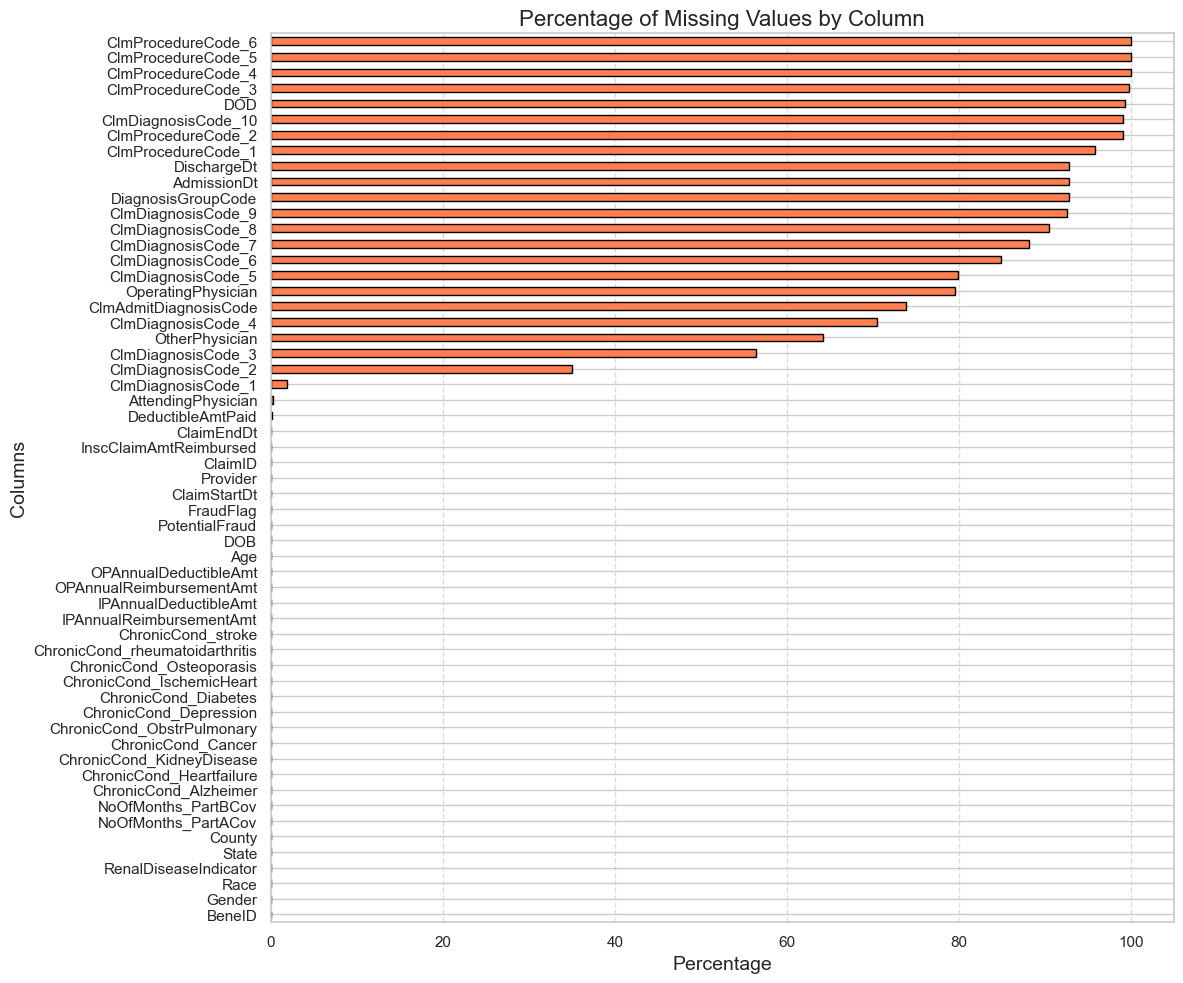

In [80]:
missing_values_percentage = all_data.isna().sum() / len(all_data) * 100

plt.figure(figsize=(12, 10))
missing_values_percentage.sort_values(ascending=True).plot(kind='barh', color='coral', edgecolor='black')
plt.title('Percentage of Missing Values by Column', fontsize=16)
plt.xlabel('Percentage', fontsize=14)
plt.ylabel('Columns', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [81]:
all_data['DOB'] = pd.to_datetime(all_data['DOB'])
all_data['DOD'] = pd.to_datetime(all_data['DOD'])

all_data['Age'] = all_data['DOD'].dt.year - all_data['DOB'].dt.year
all_data.drop(columns=['DOB'], inplace=True)


In [82]:
print(all_data['Age'].value_counts())


Age
67.0    209
69.0    189
73.0    170
77.0    163
68.0    161
       ... 
51.0      6
36.0      5
39.0      4
95.0      3
42.0      2
Name: count, Length: 63, dtype: int64


In [83]:
stats = all_data['Age'].describe()
stats

count    4131.000000
mean       74.509078
std        11.094448
min        36.000000
25%        68.000000
50%        75.000000
75%        82.000000
max       100.000000
Name: Age, dtype: float64

In [84]:
# mean i 50% są bardzo podobne


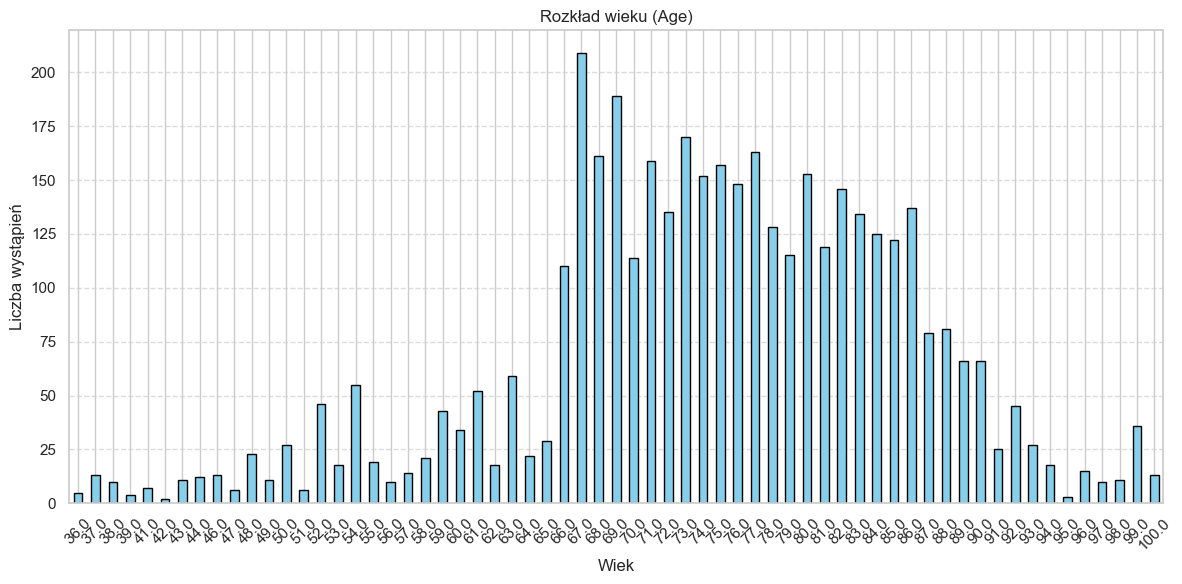

In [85]:
import matplotlib.pyplot as plt

age_counts = all_data['Age'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
age_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Rozkład wieku (Age)')
plt.xlabel('Wiek')
plt.ylabel('Liczba wystąpień')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [86]:
all_data['Age'].fillna(all_data['Age'].median(), inplace=True)


C:\Users\Marynki\AppData\Local\Temp\ipykernel_24692\1656550493.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data['Age'].fillna(all_data['Age'].median(), inplace=True)


In [87]:
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0


In [88]:
print(all_data['PotentialFraud'].isnull().sum())

0


In [89]:
all_data['isAlive'] = all_data['DOD'].isna().astype(int)
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1


In [90]:
 #Czy występuje niezrównoważenie klas (np. dużo więcej 0 niż 1)?

print(all_data['PotentialFraud'].value_counts())
print(all_data['PotentialFraud'].value_counts(normalize=True) * 100)


PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64
PotentialFraud
No     61.878931
Yes    38.121069
Name: proportion, dtype: float64


Over/Undesampling wyrównanie klasy - to zalezy przemyślec na podstawie liczby row - przy dużej undersampling, jak mala liczba danych oversampling

In [91]:
# Tak jest więcej nie oszust ok 61% a 38 % jest oszustw

#  Czy kolumna istnieje i ma odpowiedni typ (binary, Yes/No, 0/1)?
#  Czy występuje niezrównoważenie klas (np. dużo więcej 0 niż 1)?
#  Czy klasy są poprawnie zakodowane?

# Tak mamy w provider data dwie kolumny 0/1

In [92]:
#Czy są zduplikowane wiersze (df.duplicated().sum())?

all_data.duplicated().sum()

#Nie ma

0

In [93]:
#Czy są zduplikowane identyfikatory (Provider, ClaimID itd.)?
print('Zduplikowane ClaimID:', all_data['ClaimID'].duplicated().sum())
print('Zduplikowane BeneID:', all_data['BeneID'].duplicated().sum())
print('Zduplikowane Provider:', all_data['Provider'].duplicated().sum())


Zduplikowane ClaimID: 0
Zduplikowane BeneID: 419655
Zduplikowane Provider: 552801


BeneID i Provider się powtarzają. Sprawdzmy ile przeciętnie claimów jest per clienta, a ile jest per clienta frauda.

In [94]:
avg_claims_per_client = all_data.groupby('BeneID')['ClaimID'].nunique().mean()
print(f"Średnia liczba zgłoszeń na klienta: {avg_claims_per_client:.2f}")

# Średnio mamy 4 claimy.

Średnia liczba zgłoszeń na klienta: 4.03


In [95]:

fraud_providers = all_data[all_data['PotentialFraud'] == 'Yes']['Provider'].unique()
fraud_clients = all_data[all_data['Provider'].isin(fraud_providers)]

avg_claims_per_fraud_client = fraud_clients.groupby('BeneID')['ClaimID'].nunique().mean()
print(f"Średnia liczba zgłoszeń na klienta z fraudowym providerem: {avg_claims_per_fraud_client:.2f}")


Średnia liczba zgłoszeń na klienta z fraudowym providerem: 2.53


In [96]:
# Średnia liczba zgłoszen na klienta jest 2.53, czyli raczej ten który nie korzysta intensywnie 

In [97]:
# A co z żyjący i nie żyjący 


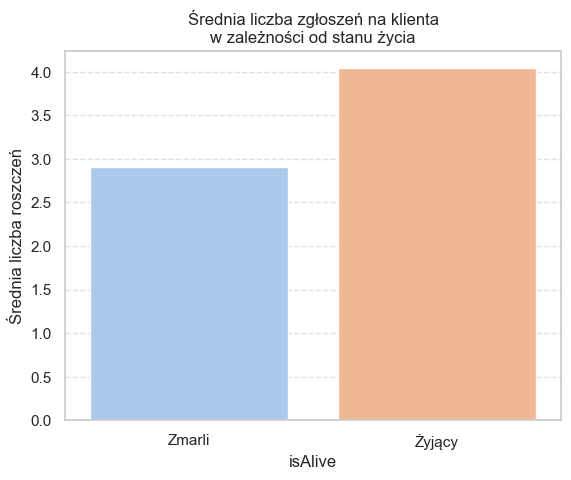

In [98]:
claims_per_client = all_data.groupby(['BeneID', 'isAlive'])['ClaimID'].nunique().reset_index()
avg_claims_alive_status = claims_per_client.groupby('isAlive')['ClaimID'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=avg_claims_alive_status.index, y=avg_claims_alive_status.values, palette='pastel')
plt.xticks([0, 1], ['Zmarli', 'Żyjący'])
plt.ylabel('Średnia liczba roszczeń')
plt.title('Średnia liczba zgłoszeń na klienta\nw zależności od stanu życia')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [99]:
# Więcej fraudów chociaz niewiele więcej jest na żyjących

WasOperated
0    443764
1    114447
Name: count, dtype: int64
WasOperated
0    79.5
1    20.5
Name: proportion, dtype: float64


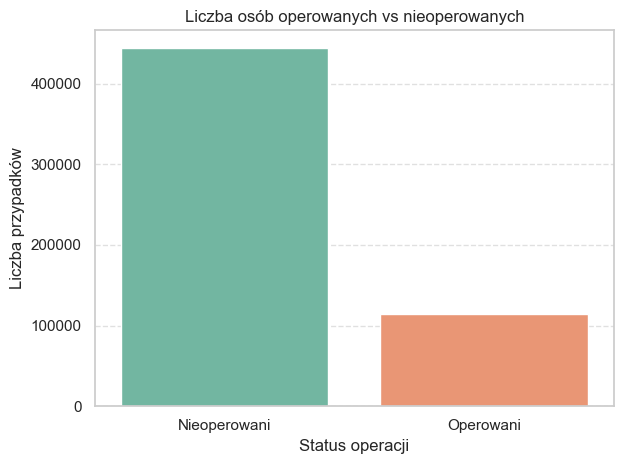

In [100]:
all_data['WasOperated'] = all_data['OperatingPhysician'].notna().astype(int)
operated_counts = all_data['WasOperated'].value_counts()
operated_percent = all_data['WasOperated'].value_counts(normalize=True) * 100
print(operated_counts)
print(operated_percent.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='WasOperated', data=all_data, palette='Set2')
plt.xticks([0, 1], ['Nieoperowani', 'Operowani'])
plt.title('Liczba osób operowanych vs nieoperowanych')
plt.ylabel('Liczba przypadków')
plt.xlabel('Status operacji')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [101]:
# Widać wyrażna tendencje że nie operowani raczej jest fraud
# A wrod operowanych to jakie operacje byly sfingwane

In [102]:
fraud_operated = all_data[
    (all_data['WasOperated'] == 1) & 
    (all_data['FraudFlag'] == 1)
]

fraud_by_diag = fraud_operated.groupby('DiagnosisGroupCode')['ClaimID'].count().sort_values(ascending=False)
print(fraud_by_diag.head(10))


DiagnosisGroupCode
286    59
864    55
316    53
252    52
862    51
242    50
244    48
248    48
303    47
307    47
Name: ClaimID, dtype: int64


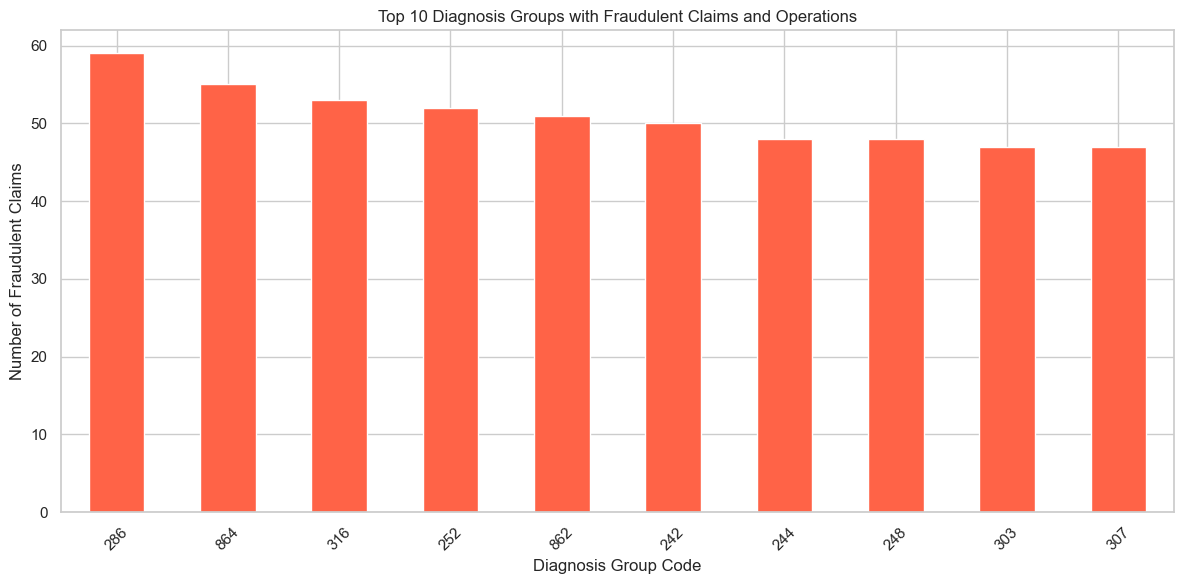

In [103]:
fraud_by_diag.head(10).plot(kind='bar', figsize=(12,6), color='tomato')
plt.title('Top 10 Diagnosis Groups with Fraudulent Claims and Operations')
plt.ylabel('Number of Fraudulent Claims')
plt.xlabel('Diagnosis Group Code')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
print(all_data.columns.tolist())

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'Chron

In [105]:
fraud_with_diag = all_data[
    (all_data['FraudFlag'] == 1) &
    (all_data['DiagnosisGroupCode'].notna())
]

count_fraud_with_diag = fraud_with_diag.shape[0]
print(f"Liczba fraudów z wypełnionym DiagnosisGroupCode: {count_fraud_with_diag}")


Liczba fraudów z wypełnionym DiagnosisGroupCode: 23402


In [106]:
fraud_with_diag = all_data[
    (all_data['FraudFlag'] == 1) &
    (all_data['DiagnosisGroupCode'].notna())
]

all_claims_with_diag = all_data[
    (all_data['DiagnosisGroupCode'].notna())
]
count_fraud_with_diag = fraud_with_diag.shape[0]
total_fraud = all_claims_with_diag.shape[0]

percentage = (count_fraud_with_diag / total_fraud) * 100

print(f"Procent fraudów z wypełnionym DiagnosisGroupCode: {percentage:.2f}%")


Procent fraudów z wypełnionym DiagnosisGroupCode: 57.82%


In [107]:
# Ponad połowe ma wypelnione 57.82%

In [108]:
# A jak od racy fraud zalezy 

Race
1    37.862287
2    36.455787
3    45.457773
5    44.035533
Name: FraudFlag, dtype: float64


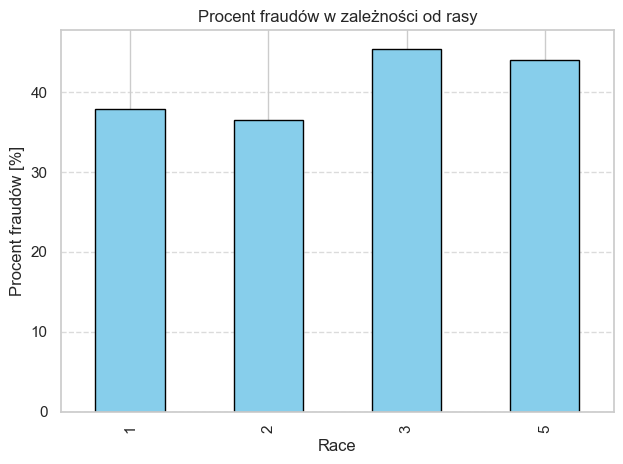

In [109]:
fraud_by_race = all_data.groupby('Race')['FraudFlag'].mean() * 100
print(fraud_by_race)

fraud_by_race.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Procent fraudów w zależności od rasy')
plt.xlabel('Race')
plt.ylabel('Procent fraudów [%]')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



Najwięcej jest fraudów w rasie 3 i 5
Nie ma wsród fraudow Azjatyckich danych a najwięcej jest fraudow z Hispanic

<Axes: xlabel='Race'>

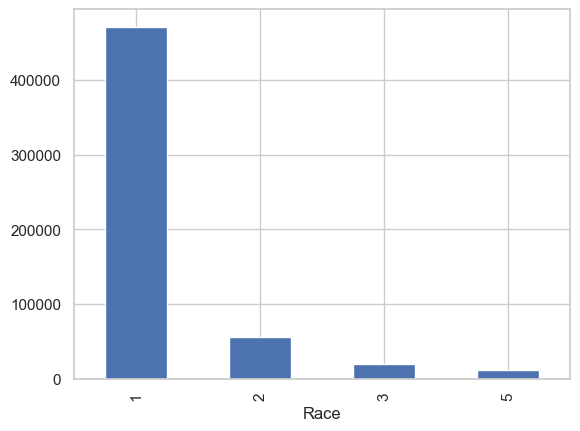

In [110]:
all_data['Race'].value_counts().plot(kind='bar')

In [111]:
fraud_counts_gender = all_data[all_data['FraudFlag'] == 1].groupby('Gender').size()
print(fraud_counts_gender)

Gender
1     89683
2    123113
dtype: int64


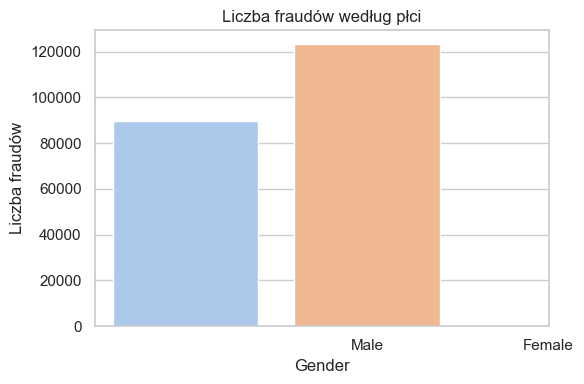

In [112]:
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts_gender.index, y=fraud_counts_gender.values, palette='pastel')
plt.title('Liczba fraudów według płci')
plt.xlabel('Gender')
plt.ylabel('Liczba fraudów')
plt.xticks(ticks=fraud_counts_gender.index, labels=['Male', 'Female']) 
plt.tight_layout()
plt.show()

In [113]:
fraud_ratio_gender = all_data.groupby('Gender')['FraudFlag'].mean() * 100
fraud_ratio_gender

Gender
1    38.147233
2    38.102032
Name: FraudFlag, dtype: float64

Jest więcej fraudow na mezczyznach ilosciowo ale procentowo jest wyrownanie

In [114]:
# Ile per dekada jest fraudow

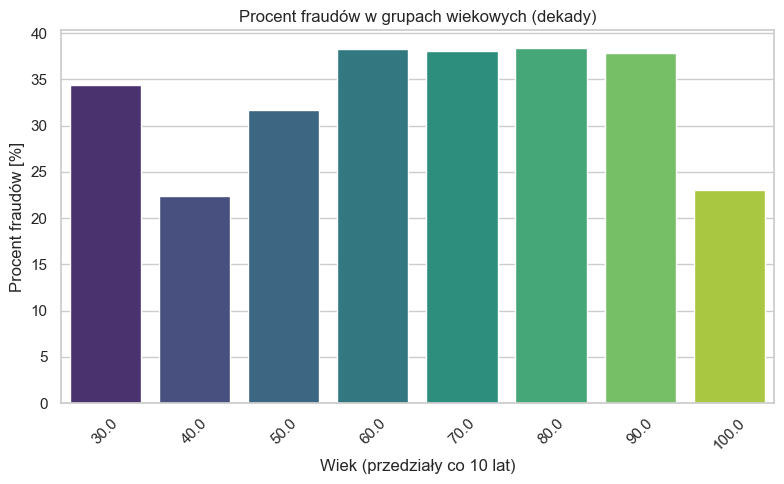

In [115]:
all_data['AgeGroup'] = (all_data['Age'] // 10) * 10

fraud_by_agegroup = all_data[all_data['FraudFlag'] == 1].groupby('AgeGroup').size()
total_by_agegroup = all_data.groupby('AgeGroup').size()
fraud_ratio = (fraud_by_agegroup / total_by_agegroup) * 100

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_ratio.index, y=fraud_ratio.values, palette='viridis')
plt.title('Procent fraudów w grupach wiekowych (dekady)')
plt.xlabel('Wiek (przedziały co 10 lat)')
plt.ylabel('Procent fraudów [%]')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [116]:
# Najmniej jest fraudow la 40 latkow i 100 latków 

In [117]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

In [118]:
alzheimers = all_data[all_data['ChronicCond_Alzheimer'] == 1]
fraud_ratio_alzheimers = alzheimers['FraudFlag'].mean() * 100
print(f'Procent fraudów wśród chorych na Alzheimera: {fraud_ratio_alzheimers:.2f}%')


Procent fraudów wśród chorych na Alzheimera: 38.49%


In [119]:
chronic_conditions = [
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke'
]

fraud_percentages = {}

for cond in chronic_conditions:
    subset = all_data[all_data[cond] == 1]
    fraud_percent = subset[subset['FraudFlag'] == 1].shape[0] / all_data[all_data['FraudFlag'] == 1].shape[0] * 100
    fraud_percentages[cond] = fraud_percent

fraud_percent_df = pd.DataFrame.from_dict(fraud_percentages, orient='index', columns=['Fraud %']).sort_values(by='Fraud %', ascending=False)
print(fraud_percent_df)

#ile jest fraudow per choroba przewlekla na wszystkie fraudy

                                   Fraud %
ChronicCond_IschemicHeart        76.369857
ChronicCond_Diabetes             70.849546
ChronicCond_Heartfailure         59.609203
ChronicCond_Depression           43.510216
ChronicCond_KidneyDisease        42.222128
ChronicCond_Alzheimer            40.577360
ChronicCond_ObstrPulmonary       32.006241
ChronicCond_Osteoporasis         31.834715
ChronicCond_rheumatoidarthritis  31.411775
ChronicCond_Cancer               15.309498
ChronicCond_stroke               10.524634


Najczęsciej oszukują na chronic 
ChronicCond_IschemicHeart        76.369857
ChronicCond_Diabetes             70.849546
ChronicCond_Heartfailure         59.609203
ChronicCond_Depression           43.510216

In [120]:
all_data.columns


Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

c:\Users\Marynki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


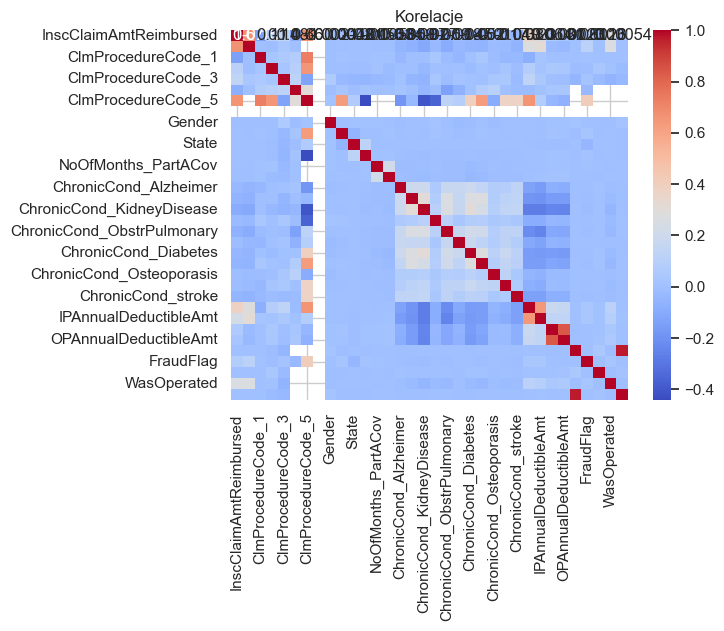

In [121]:
corr_df = all_data.copy()

correlation = corr_df.select_dtypes(include=['number']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()


In [122]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

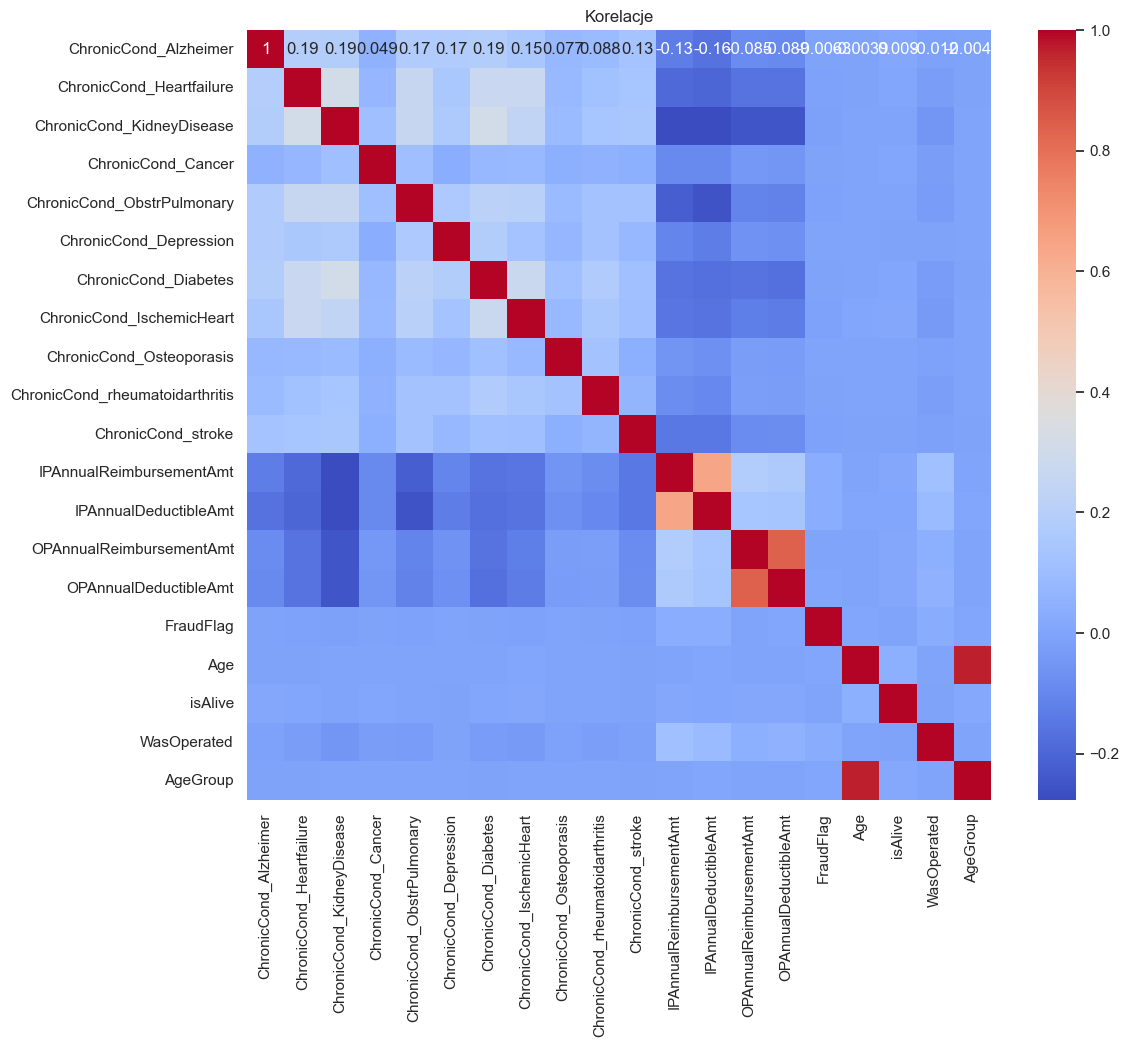

In [123]:
cols = ['ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
        'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
        'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
        'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
        'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
        'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
        'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
        'OPAnnualDeductibleAmt', 'PotentialFraud', 'FraudFlag', 'Age',
        'isAlive', 'WasOperated', 'AgeGroup']

corr_df = all_data[cols]

correlation = corr_df.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

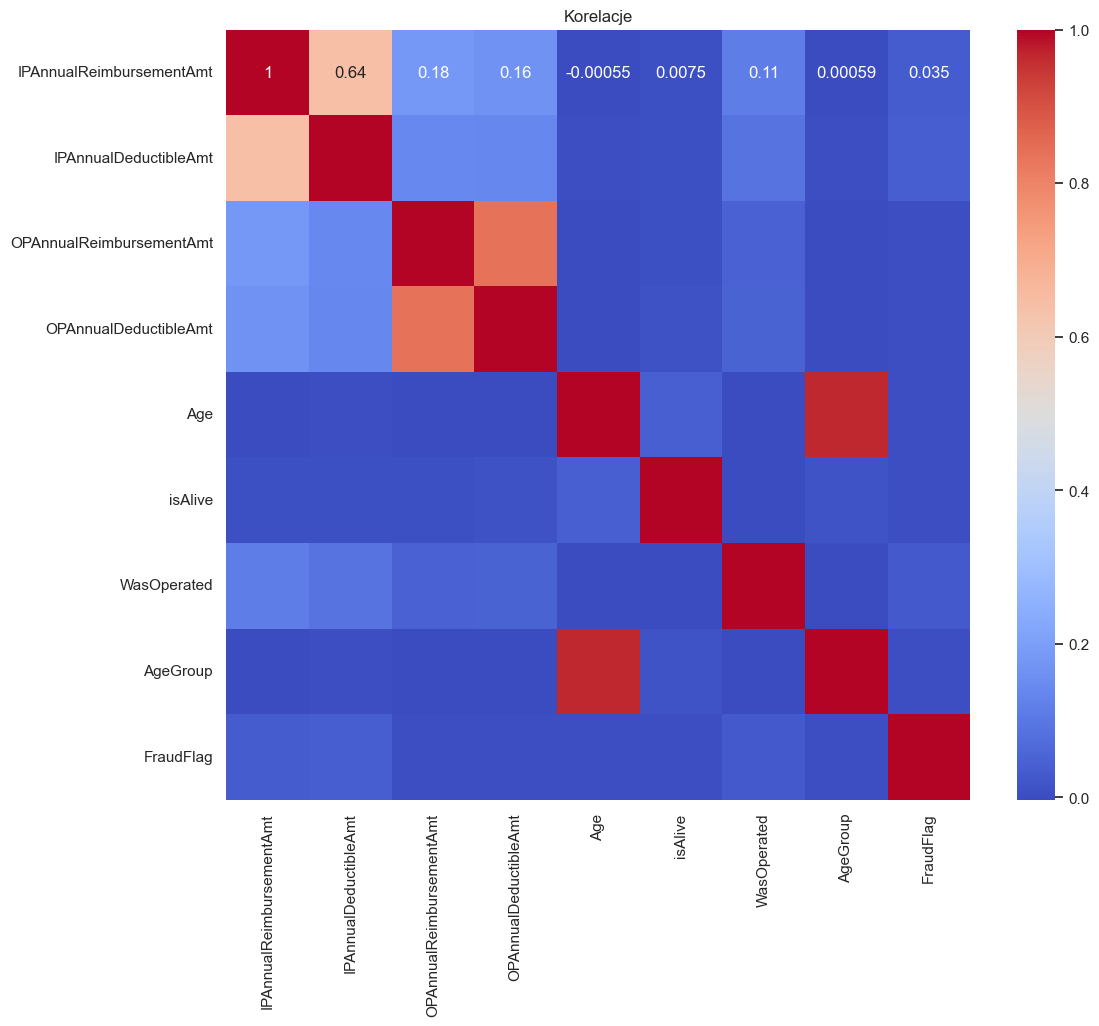

In [124]:
cols = [ 'IPAnnualReimbursementAmt',
        'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
        'OPAnnualDeductibleAmt', 'PotentialFraud', 'Age',
        'isAlive', 'WasOperated', 'AgeGroup', 'FraudFlag']

corr_df = all_data[cols]

correlation = corr_df.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [125]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

c:\Users\Marynki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


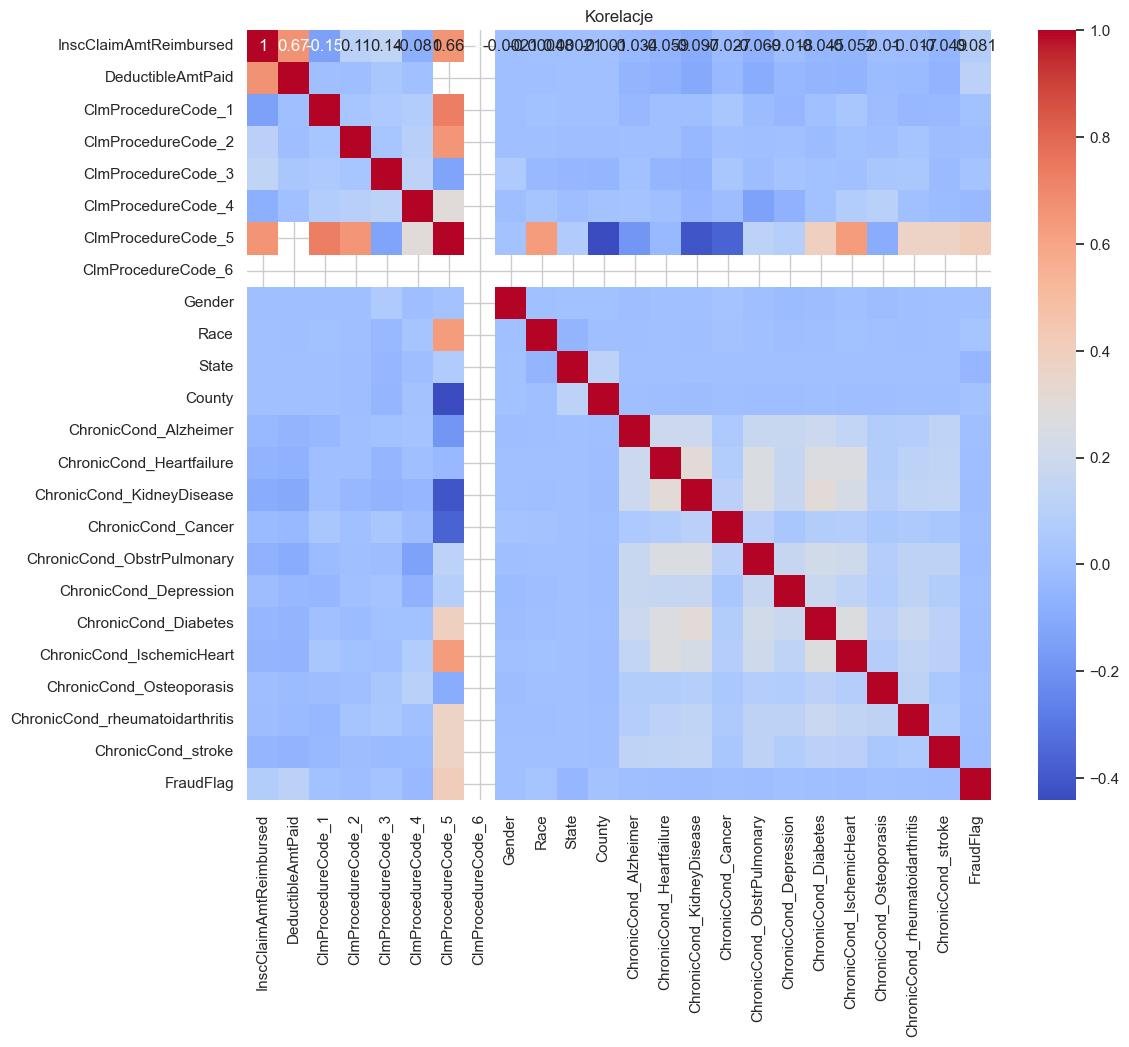

In [126]:
cols = ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke','FraudFlag']

corr_df2 = all_data[cols]

correlation = corr_df2.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [127]:
# widaź wyrazna zależnoc CLM_procedure_5

In [128]:
fraud_counts_nonnull = all_data[(all_data['FraudFlag'] == 1) & (all_data['ClmProcedureCode_5'].notna())]['ClmProcedureCode_5'].value_counts()
print(fraud_counts_nonnull)


ClmProcedureCode_5
4139.0    2
5185.0    1
9971.0    1
2724.0    1
9982.0    1
Name: count, dtype: int64


In [129]:
total_counts = all_data['ClmProcedureCode_5'].value_counts(dropna=False)
fraud_counts = all_data[all_data['FraudFlag'] == 1]['ClmProcedureCode_5'].value_counts(dropna=False)

fraud_percent = (fraud_counts / total_counts) * 100
fraud_percent = fraud_percent.sort_values(ascending=False)

print(fraud_percent)


ClmProcedureCode_5
5185.0    100.000000
9971.0    100.000000
9982.0    100.000000
4139.0     66.666667
2724.0     50.000000
NaN        38.120609
4422.0           NaN
Name: count, dtype: float64


In [130]:
all_data.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabe

In [131]:
#all_data = all_data.drop(['ClaimStartDt', 'ClaimEndDt','PotentialFraud', 'AgeGroup', 'DOD', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov','OPAnnualDeductibleAmt', 'IPAnnualDeductibleAmt'],axis=1)
all_data = all_data.drop(['ClaimStartDt', 'ClaimEndDt'],axis=1)


In [132]:
all_data.columns

Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
       'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
       'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DOD',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary',
       'ChronicCond_Depression', 'ChronicCond_Diabetes',
       'ChronicCond_IschemicHea

In [133]:
all_data = all_data.drop(['DeductibleAmtPaid'],axis=1)

c:\Users\Marynki\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


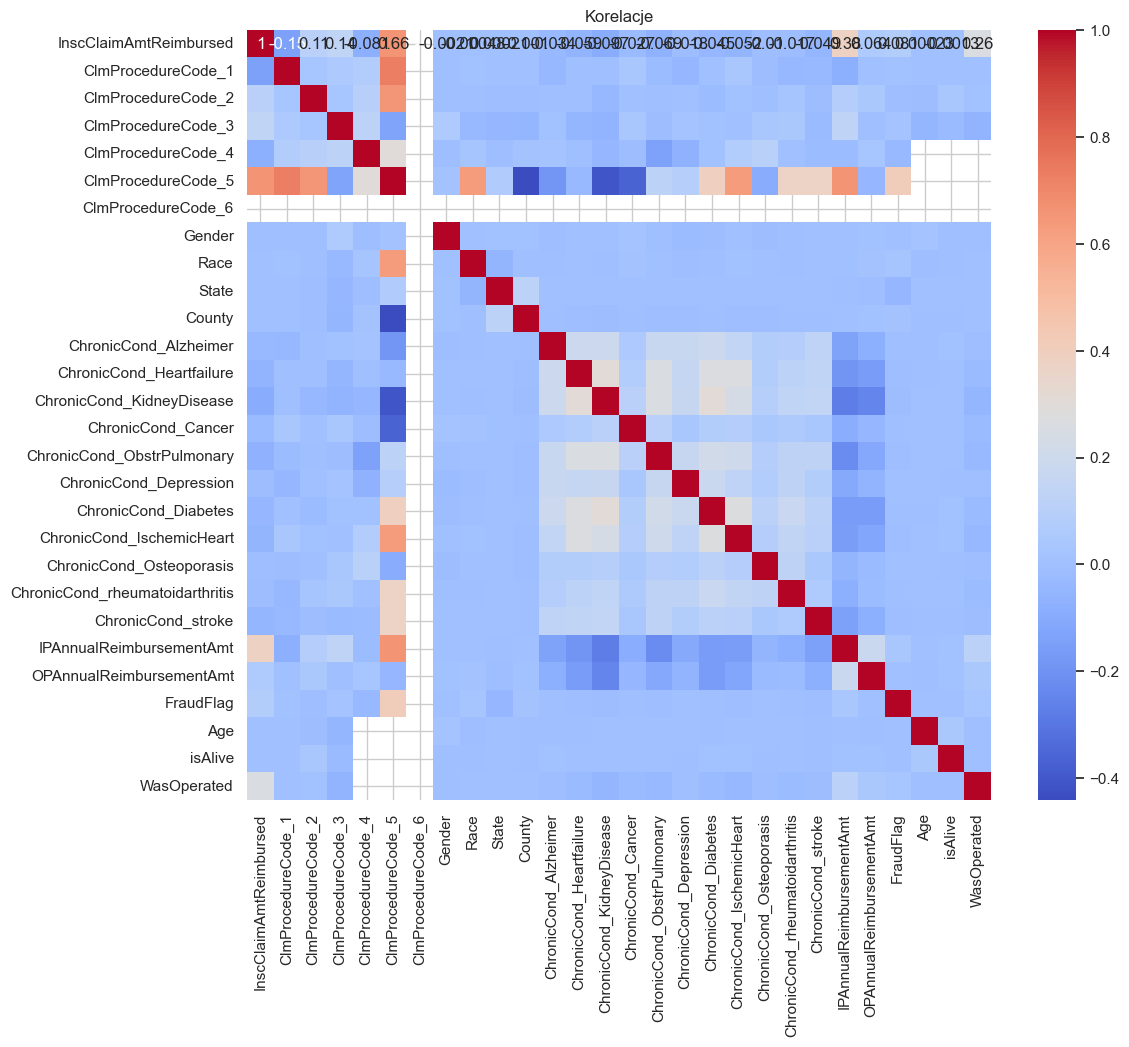

In [136]:
cols = ['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10',
       'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
       'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'OPAnnualReimbursementAmt', 'FraudFlag', 'Age', 'isAlive',
       'WasOperated']

corr_df3 = all_data[cols]

correlation = corr_df3.select_dtypes(include=['number']).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelacje')
plt.show()

In [137]:
# Melt: przekształcenie danych z szerokiego formatu do długiego
all_data_melted = all_data.melt(var_name='original_column', value_name='value')
# Dodanie nowej kolumny z ostatnią literą nazwy kolumny
all_data_melted['last_letter'] = all_data_melted['original_column'].str[-1]



In [138]:
print(all_data_melted.head())

  original_column      value last_letter
0          BeneID  BENE11001           D
1          BeneID  BENE11001           D
2          BeneID  BENE11001           D
3          BeneID  BENE11011           D
4          BeneID  BENE11014           D


In [139]:



# Wybierz kolumny, których nazwa kończy się cyfrą 1-9
digit_cols = ['ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10']
# Stwórz pustą kolumnę docelową
all_data['digit_found'] = None
# Iteruj po wybranych kolumnach i przypisz cyfrę tam, gdzie wartość == 1
for col in digit_cols:
    digit = col[-1]
    mask = all_data[col] == 1
    all_data.loc[mask, 'digit_found'] = digit
display(all_data.head())

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive,WasOperated,AgeGroup,digit_found
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1,0,70.0,None
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,1,70.0,None
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,0,70.0,None
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1,1,70.0,None
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1,1,70.0,None


In [140]:
display(all_data.head())

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive,WasOperated,AgeGroup,digit_found
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1,0,70.0,None
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,1,70.0,None
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,0,70.0,None
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1,1,70.0,None
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1,1,70.0,None


Analiza ze względu na rasę beneficjenta

In [141]:
fraud_percentage_df = all_data.groupby('Race')['FraudFlag'].mean().reset_index()
fraud_percentage_df['FraudFlag'] = fraud_percentage_df['FraudFlag'] * 100
fraud_percentage_df.rename(columns={'FraudFlag': 'Fraud Percentage'}, inplace=True)

print(fraud_percentage_df)


   Race  Fraud Percentage
0     1         37.862287
1     2         36.455787
2     3         45.457773
3     5         44.035533


In [142]:
fraud_percentage_df = all_data.groupby(['Race', 'AgeGroup']).agg(
    FraudFlag_mean=('FraudFlag', 'mean'),
    count=('FraudFlag', 'size')  # liczba wierszy w grupie
).reset_index()
fraud_percentage_df['FraudFlag_mean'] = fraud_percentage_df['FraudFlag_mean'] * 100
fraud_percentage_df.rename(columns={'FraudFlag_mean': 'Fraud Percentage'}, inplace=True)

print(fraud_percentage_df)

    Race  AgeGroup  Fraud Percentage   count
0      1      30.0         38.095238      21
1      1      40.0         25.925926      54
2      1      50.0         29.268293     205
3      1      60.0         40.486409     699
4      1      70.0         37.862903  468823
5      1      80.0         38.680203     985
6      1      90.0         36.440678     236
7      1     100.0         23.076923      13
8      2      30.0         27.272727      11
9      2      40.0         17.857143      28
10     2      50.0         35.483871      31
11     2      60.0         31.683168     101
12     2      70.0         36.480555   55361
13     2      80.0         32.352941     102
14     2      90.0         66.666667       6
15     3      50.0         75.000000       4
16     3      60.0         29.824561      57
17     3      70.0         45.503212   19614
18     3      80.0         41.935484      31
19     3      90.0         44.444444       9
20     5      40.0          0.000000       3
21     5  

# Rasa nie ma znaczącego wpływu na oszustwa

In [143]:
cols = [
    'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
    'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
    'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
    'ClmDiagnosisCode_10'
]

# Tworzymy nową kolumnę 'DiagnosisCount' zliczającą ile jest wartości nie-NaN w tych kolumnach
all_data['DiagnosisCount'] = all_data[cols].notnull().sum(axis=1)

# Sprawdź efekt
print(all_data[['DiagnosisCount']].head())

   DiagnosisCount
0               9
1               3
2               6
3               9
4               9


In [144]:
cols = [
    'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
    'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
]

# Tworzymy nową kolumnę 'ProceduresCount' zliczającą ile jest wartości nie-NaN w tych kolumnach
all_data['ProceduresCount'] = all_data[cols].notnull().sum(axis=1)

# Sprawdź efekt
print(all_data[['ProceduresCount']].head())

   ProceduresCount
0                0
1                1
2                0
3                1
4                1


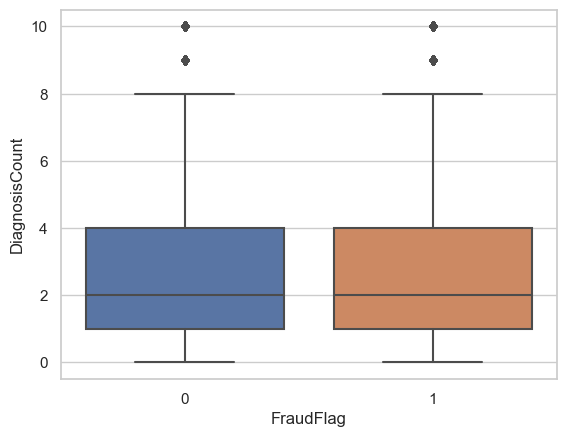

Korelacja Pearsona między DiagnosisCount a FraudFlag: 0.0655238076835681


In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='FraudFlag', y='DiagnosisCount', data=all_data)
plt.show()

correlation = all_data['DiagnosisCount'].corr(all_data['FraudFlag'])
print(f"Korelacja Pearsona między DiagnosisCount a FraudFlag: {correlation}")

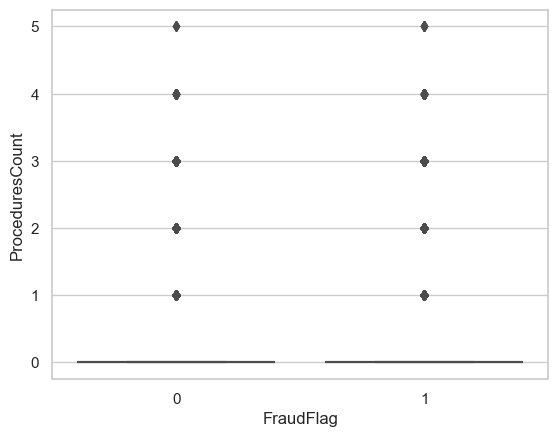

Korelacja Pearsona między ProceduresCount a FraudFlag: 0.07912935793652816


In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='FraudFlag', y='ProceduresCount', data=all_data)
plt.show()

correlation = all_data['ProceduresCount'].corr(all_data['FraudFlag'])
print(f"Korelacja Pearsona między ProceduresCount a FraudFlag: {correlation}")

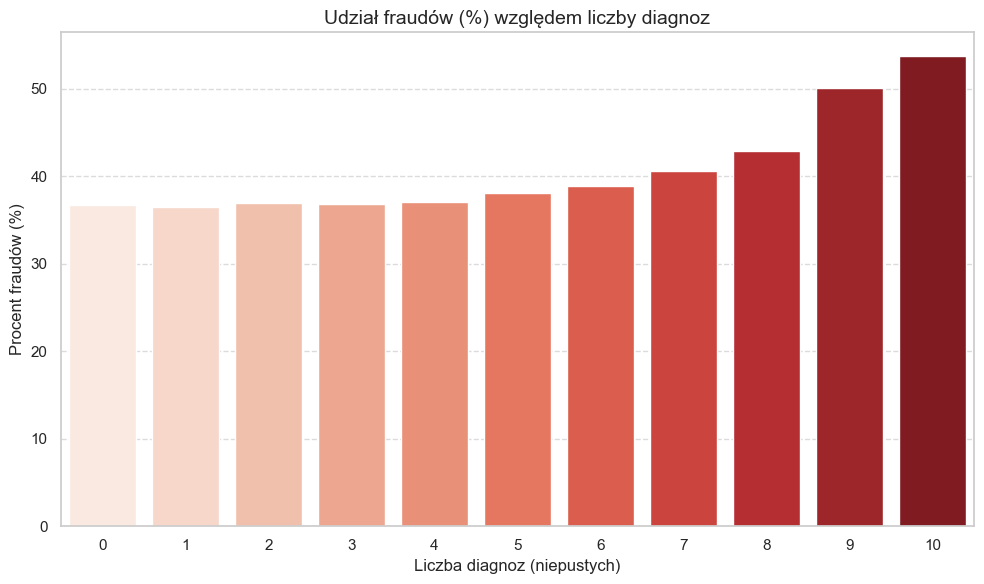

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
diag_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]
all_data['DiagCount'] = all_data[diag_cols].notna().sum(axis=1)
all_data['FraudFlag'] = pd.to_numeric(all_data['FraudFlag'], errors='coerce')
summary = all_data.groupby('DiagCount')['FraudFlag'].agg(['sum', 'count']).reset_index()
summary['FraudPercent'] = (summary['sum'] / summary['count']) * 100
plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x='DiagCount', y='FraudPercent', palette='Reds')
plt.title('Udział fraudów (%) względem liczby diagnoz', fontsize=14)
plt.xlabel('Liczba diagnoz (niepustych)', fontsize=12)
plt.ylabel('Procent fraudów (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

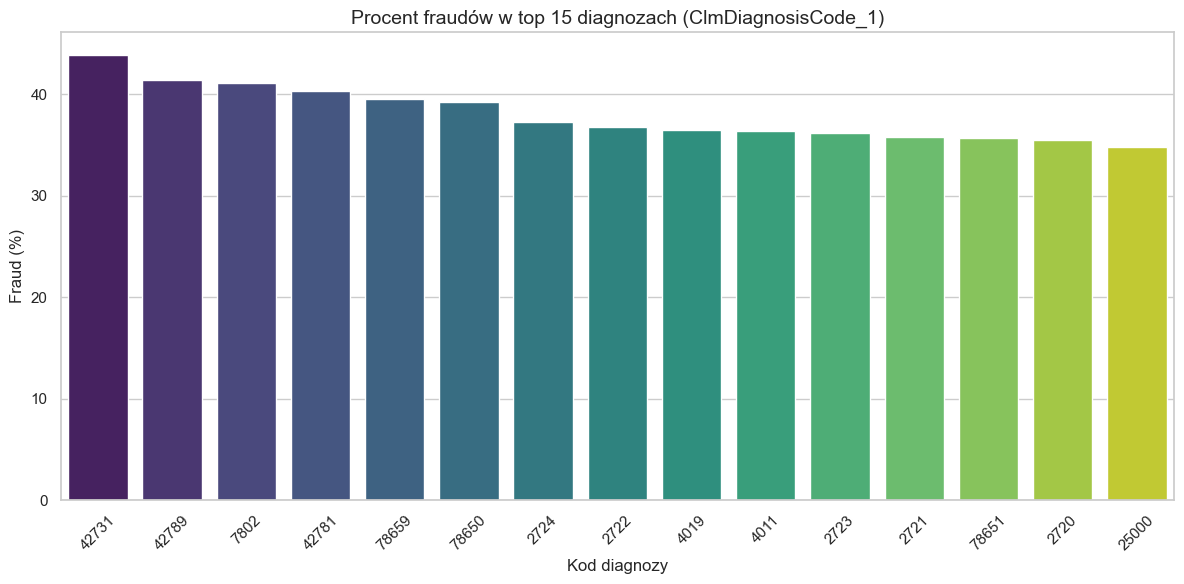

In [148]:
top_15 = (
    all_data['ClmDiagnosisCode_1']
    .value_counts()
    .head(15)
    .index
)
df_top15 = all_data[all_data['ClmDiagnosisCode_1'].isin(top_15)]
diag_summary = (
    df_top15
    .groupby('ClmDiagnosisCode_1')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
diag_summary['fraud_percent'] = (diag_summary['fraud_count'] / diag_summary['total']) * 100
diag_summary = diag_summary.sort_values(by='fraud_percent', ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    data=diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='viridis'
)
plt.title('Procent fraudów w top 15 diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

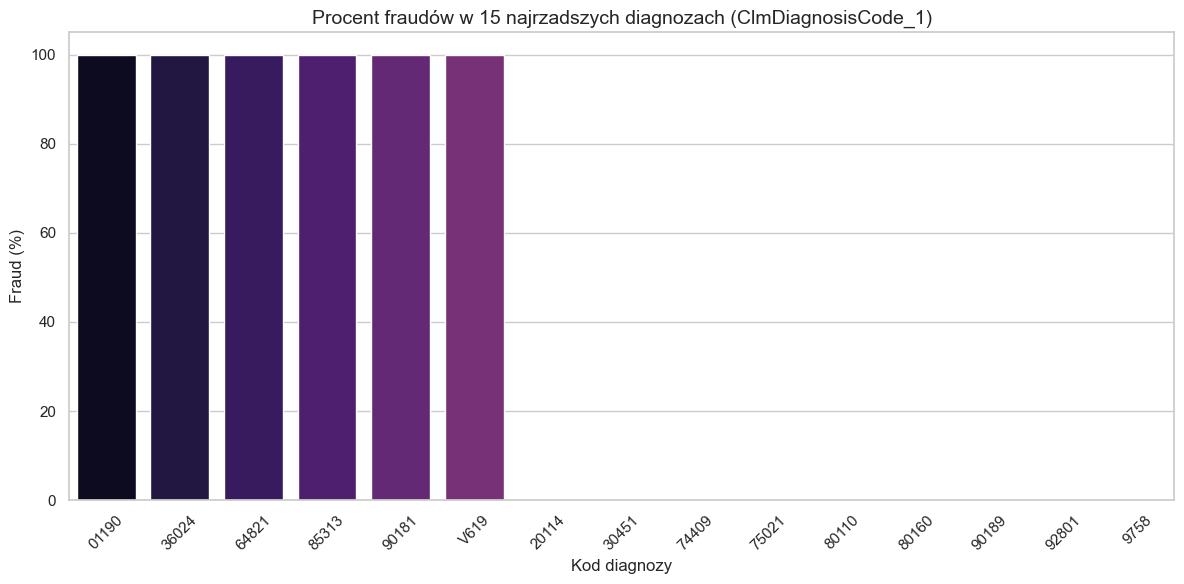

In [149]:
# Znajdź 15 najrzadszych diagnoz (pomijając NaN)
rare_15 = (
    all_data['ClmDiagnosisCode_1']
    .value_counts(ascending=True)
    .dropna()
    .head(15)
    .index
)
# Filtrowanie danych tylko do tych diagnoz
df_rare15 = all_data[all_data['ClmDiagnosisCode_1'].isin(rare_15)]
# Podsumowanie fraudów i liczby przypadków
rare_diag_summary = (
    df_rare15
    .groupby('ClmDiagnosisCode_1')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
rare_diag_summary['fraud_percent'] = (rare_diag_summary['fraud_count'] / rare_diag_summary['total']) * 100
rare_diag_summary = rare_diag_summary.sort_values(by='fraud_percent', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=rare_diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='magma'
)
plt.title('Procent fraudów w 15 najrzadszych diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

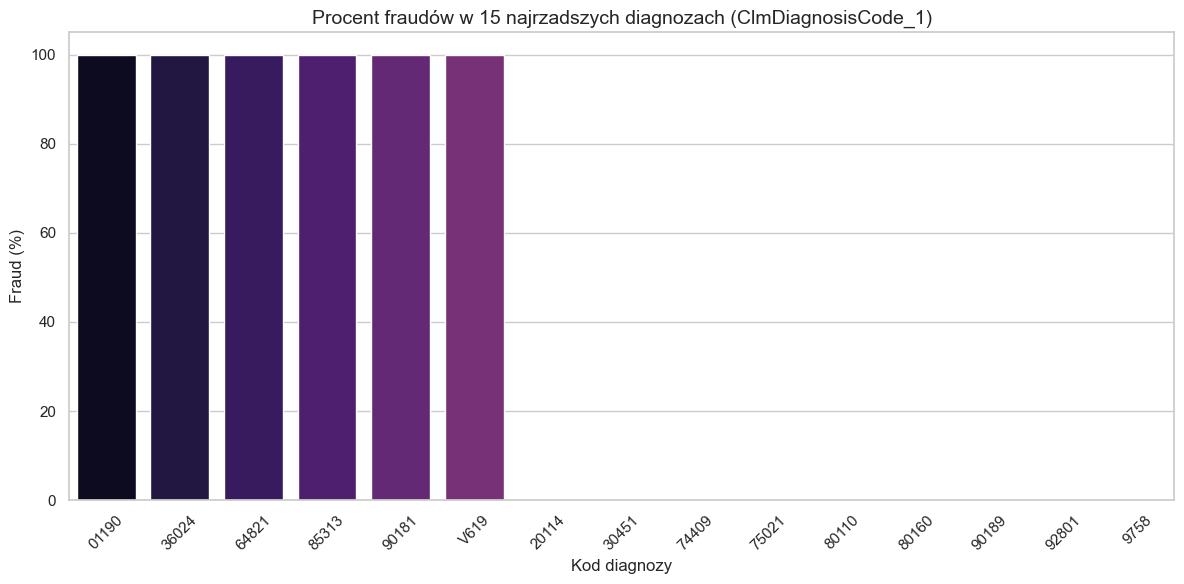

In [150]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=rare_diag_summary,
    x='ClmDiagnosisCode_1',
    y='fraud_percent',
    palette='magma'
)
plt.title('Procent fraudów w 15 najrzadszych diagnozach (ClmDiagnosisCode_1)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

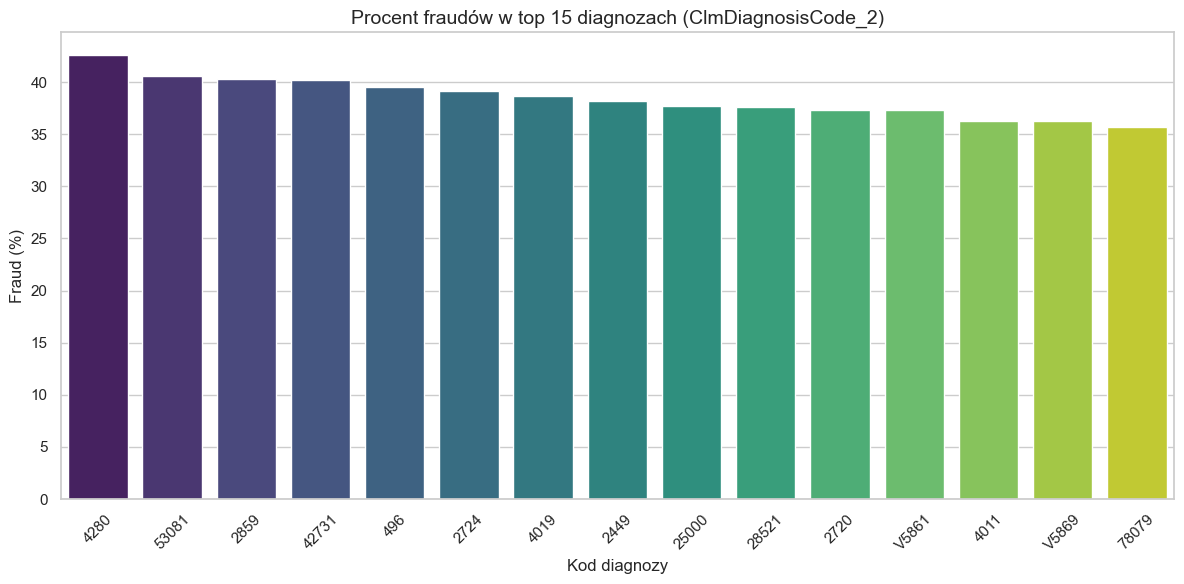

In [151]:
top_15_2= (
    all_data['ClmDiagnosisCode_2']
    .value_counts()
    .head(15)
    .index
)
df_top15 = all_data[all_data['ClmDiagnosisCode_2'].isin(top_15_2)]
diag_summary = (
    df_top15
    .groupby('ClmDiagnosisCode_2')['FraudFlag']
    .agg(
        total='count',
        fraud_count='sum'
    )
    .reset_index()
)
diag_summary['fraud_percent'] = (diag_summary['fraud_count'] / diag_summary['total']) * 100
diag_summary = diag_summary.sort_values(by='fraud_percent', ascending=False)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    data=diag_summary,
    x='ClmDiagnosisCode_2',
    y='fraud_percent',
    palette='viridis'
)
plt.title('Procent fraudów w top 15 diagnozach (ClmDiagnosisCode_2)', fontsize=14)
plt.xlabel('Kod diagnozy', fontsize=12)
plt.ylabel('Fraud (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [152]:
#Analiza fraudów według lekarzy (AttendingPhysician, OperatingPhysician, OtherPhysician)
# Top 10 lekarzy z największą liczbą fraudów
top_phys_frauds = all_data[all_data['PotentialFraud'] == 'Yes'] \
    ['AttendingPhysician'].value_counts().head(10)
print(top_phys_frauds)
top_phys_ids = top_phys_frauds.index.tolist()
top_phys_data = all_data[all_data['AttendingPhysician'].isin(top_phys_ids)]

AttendingPhysician
PHY330576    2534
PHY350277    1628
PHY412132    1321
PHY423534    1223
PHY314027    1200
PHY327046    1181
PHY338032    1158
PHY357120    1156
PHY337425    1156
PHY341578    1133
Name: count, dtype: int64


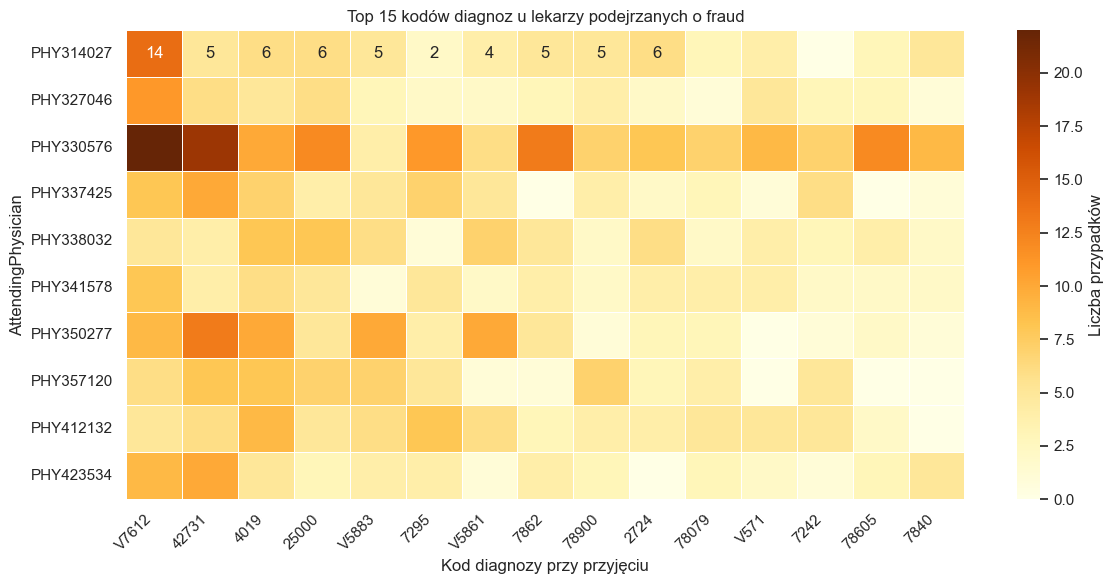

In [153]:
fraud_phys_data = all_data[
    (all_data['PotentialFraud'] == 'Yes') &
    (all_data['AttendingPhysician'].isin(top_phys_ids))
]
fraud_diag_crosstab = pd.crosstab(fraud_phys_data['AttendingPhysician'], fraud_phys_data['ClmAdmitDiagnosisCode'])

# Wyciągnij top 15 najczęstszych kodów diagnozy wśród tych lekarzy
top_diag_codes = fraud_phys_data['ClmAdmitDiagnosisCode'].value_counts().head(15).index
# Filtrowanie tabeli tylko do tych kodów
filtered_crosstab = fraud_diag_crosstab[top_diag_codes]

plt.figure(figsize=(12, 6))
sns.heatmap(filtered_crosstab, cmap='YlOrBr', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Liczba przypadków'})
plt.title("Top 15 kodów diagnoz u lekarzy podejrzanych o fraud")
plt.xlabel("Kod diagnozy przy przyjęciu")
plt.ylabel("AttendingPhysician")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [154]:
columns_of_interest = ['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DischargeDt',
       'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DOD', 'Gender', 'Race',
       'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov',
       'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary',
       'ChronicCond_Depression', 'ChronicCond_Diabetes',
       'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis',
       'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke',
       'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
       'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age',
       'PotentialFraud', 'FraudFlag', 'isAlive', 'WasOperated', 'AgeGroup',
       'digit_found', 'DiagnosisCount', 'ProceduresCount', 'DiagCount']

for col in columns_of_interest:
    print(f"{col}: {all_data[col].dtype}")


BeneID: object
ClaimID: object
Provider: object
InscClaimAmtReimbursed: int64
AttendingPhysician: object
OperatingPhysician: object
OtherPhysician: object
AdmissionDt: datetime64[ns]
ClmAdmitDiagnosisCode: object
DischargeDt: datetime64[ns]
DiagnosisGroupCode: object
ClmDiagnosisCode_1: object
ClmDiagnosisCode_2: object
ClmDiagnosisCode_3: object
ClmDiagnosisCode_4: object
ClmDiagnosisCode_5: object
ClmDiagnosisCode_6: object
ClmDiagnosisCode_7: object
ClmDiagnosisCode_8: object
ClmDiagnosisCode_9: object
ClmDiagnosisCode_10: object
ClmProcedureCode_1: float64
ClmProcedureCode_2: float64
ClmProcedureCode_3: float64
ClmProcedureCode_4: float64
ClmProcedureCode_5: float64
ClmProcedureCode_6: float64
DOD: datetime64[ns]
Gender: int64
Race: int64
RenalDiseaseIndicator: object
State: int64
County: int64
NoOfMonths_PartACov: int64
NoOfMonths_PartBCov: int64
ChronicCond_Alzheimer: int64
ChronicCond_Heartfailure: int64
ChronicCond_KidneyDisease: int64
ChronicCond_Cancer: int64
ChronicCond_Obst

Przykładowy kod w Pythonie do stworzenia prostego modelu Random Forest do wykrywania oszustw (binary classification).

Wstępnego modelowanie Random Forest

In [155]:
all_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud,FraudFlag,isAlive,WasOperated,AgeGroup,digit_found,DiagnosisCount,ProceduresCount,DiagCount
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,Yes,1,1,0,70.0,None,9,0,9
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,1,70.0,None,3,1,3
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,75.0,No,0,1,0,70.0,None,6,0,6
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,NaT,2,2,0,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,75.0,No,0,1,1,70.0,None,9,1,9
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,NaT,2,1,Y,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,75.0,No,0,1,1,70.0,None,9,1,9


Co się tu dzieje:

    Definiuję, które cechy są numeryczne i kategoryczne.

    Tworzę zbiór cech X i zmienną celu y z all_data.

    Dzielę dane na trening i test, z zachowaniem proporcji klas (stratify).

    Buduję przetwarzanie danych:

        Numeryczne uzupełniamy medianą.

        Kategoryczne uzupełniamy najczęstszą wartością i kodujemy one-hot.

    Łączę to w ColumnTransformer.

    Buduję pipeline z preprocessorem i modelem Random Forest.

    Trenujeę, predykuję i wypisuję metryki klasyfikacji i ROC AUC.

In [156]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score

# 1. Definiujemy listy cech numerycznych i kategorycznych

numeric_features = [
    'InscClaimAmtReimbursed',
    'NoOfMonths_PartACov',
    'NoOfMonths_PartBCov',
    'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt',
    'Age',
    'DiagnosisCount',
    'ProceduresCount',
    'WasOperated'
]

categorical_features = [
    'Gender',
    'Race',
    'RenalDiseaseIndicator'
]

# 2. Przygotowanie danych wejściowych i targetu z all_data

X = all_data[numeric_features + categorical_features]
y = all_data['FraudFlag']

# 3. Podział na zbiór treningowy i testowy (80%/20%) ze stratifikacją wg FraudFlag

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Pipeline przetwarzania zmiennych

# Imputacja medianą dla numerycznych
numeric_transformer = SimpleImputer(strategy='median')

# Imputacja najczęstszej wartości + one-hot encoding dla kategorycznych
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Łączenie transformacji
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Pipeline z modelem RandomForestClassifier
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 6. Trening modelu
model.fit(X_train, y_train)

# 7. Predykcja i ewaluacja
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.66      0.79      0.72     69083
           1       0.50      0.34      0.41     42560

    accuracy                           0.62    111643
   macro avg       0.58      0.57      0.56    111643
weighted avg       0.60      0.62      0.60    111643

ROC AUC: 0.602414412095987


Interpretacja raportu klasyfikacji:

| Metryka                  | Znaczenie                                                                                                       |
| ------------------------ | --------------------------------------------------------------------------------------------------------------- |
| precision (precyzja)     | Ile z przewidzianych „fraud” faktycznie jest oszustwem. (np. z przewidzianych 100 fraud, ile faktycznie fraud). |
| recall (czułość)         | Ile z prawdziwych fraud udało się wykryć (np. z 100 fraud, ile model poprawnie oznaczył jako fraud).            |
| f1-score                 | Harmoniczna średnia precision i recall — ogólny balans jakości klasyfikacji dla danej klasy.                    |
| support                  | Liczba próbek danej klasy w zbiorze testowym.                                                                   |


Mwoje wyniki:

Klasa 0 (brak oszustwa):

    Precision = 0.66 → spośród prognoz „0” 66% było poprawnych

    Recall = 0.79 → model wykrył 79% wszystkich nieoszukańczych przypadków

    F1 = 0.72 → dobry kompromis między precyzją i czułością dla tej klasy

Klasa 1 (oszustwo):

    Precision = 0.50 → spośród prognoz „fraud” 50% faktycznie było fraud

    Recall = 0.34 → model wykrył tylko 34% wszystkich fraudów, czyli dużo przypadków oszustwa nie zostało wykrytych (false negatives)

    F1 = 0.41 → słabsza jakość wykrywania oszustw

Ogólna ocena:

    Accuracy = 62% — model poprawnie klasyfikuje 62% przypadków, ale uwaga: w nierównoważonych danych (gdzie fraud jest mniej liczny) accuracy może być mylące.

    ROC AUC = 0.60 — umiarkowana jakość modelu w rozróżnianiu klas (0.5 to losowy, 1.0 idealny). Wynik 0.6 jest lepszy niż losowy, ale nadal dość słaby.

Co to oznacza dla mojego modelu?

    Model jest lepszy w wykrywaniu przypadków bez oszustwa niż samych oszustw.

    Być może warto podjąć działania, by zwiększyć czułość na klasę fraud — np. przez:

        balansowanie danych (np. oversampling oszustw),

        tuning hiperparametrów modelu,

        zastosowanie innych modeli,

        zmiany w cechach,

        próby innych metryk i progów decyzyjnych.

KOLEJNE KROKI, które moge podjąć :

1. Najpierw skupić się na problemie niezbalansowanych danych (bo Fraud jest zwykle mniejszością), czyli:

    Balansowanie danych: np. SMOTE (syntetyczne generowanie przykładów fraud), undersampling klasy większości lub kombinacja.

    Dlaczego? Bo model na niezbalansowanych danych „uczy się” po prostu przewidywać klasę dominującą (brak fraud), co obniża recall na fraud.

2. Po balansowaniu:

    Zrobić Tuning hiperparametrów Random Forest — można poprawić jakość klasyfikacji.

    Zanaliza ważności cech — zobaczyć, które zmienne mają realny wpływ na wykrywanie fraud.

3. Następnie można spróbować:

    porównać jak radzą sobie inne modele — np. XGBoost, LightGBM, które często lepiej radzą sobie z nierównymi klasami.

    Zrobić zmiany  w cechach — tworzenie nowych zmiennych, selekcja cech, inżynieria cech.

    Zrobić eksperyment z progami decyzyjnymi — np. przesuwanie threshold z 0.5 na niższy, żeby zwiększyć czułość (recall) na fraud.

4. Ewaluacja:

    Użyć metryk takich jak roc_auc, recall i precision-recall curve, bo accuracy jest mylące w niezbalansowanych danych.



PLAN:
1. Wprowadź SMOTE lub inne metody balansowania na zbiorze treningowym
2. Przeprowadź tuning Random Forest (np. GridSearchCV) -Tuning hiperparametrów
3. Sprawdź ważność cech, aby rozważyć ewentualne usunięcie nieistotnych
4. Przetestuj progi decyzyjne i wypróbuj inne klasyfikatory (np. XGBoost)
5. Ewaluuj modele na zbiorze testowym i porównuj metryki recall i ROC AUC


Póki co Plan działania (skupiony tylko na Random Forest):

                                             Krok 1: Balansowanie danych (na zbiorze treningowym)

    Użyj SMOTE (Synthetic Minority Oversampling Technique) do oversamplingu klasy fraud.

    Alternatywa: prosty undersampling klasy większości, ale może prowadzić do utraty informacji.

Cel: zwiększyć recall na klasie fraud (czyli mniej „przeoczonych oszustw”)

 Zaczynam od Kroku 1: balansowania danych przy użyciu SMOTE + Random Forest w Pipeline.
W tym etapie nmoim celem jest zwiększenie skuteczności wykrywania oszustw (klasa 1), które są mniejszością w zbiorze.

Co robię w tym kroku?

    Dzielę dane na zbiór treningowy i testowy, zachowując proporcje klas (stratify=y).

    Tworzyę przetwarzanie (pipeline):

        Imputacja braków w danych numerycznych i kategorycznych.

        Kodowanie kategorycznych zmiennych (OneHot).

    Włączam SMOTE do pipeline (działa tylko na zbiorze treningowym).

    Dodaję Random Forest jako klasyfikator.

    Używam Pipeline i imbPipeline, aby zintegrować przetwarzanie + balansowanie + model.

Wymagane pakiety (jeśli nie mam SMOTE):

In [157]:
pip install imbalanced-learn


Kod – SMOTE + RandomForest + Pipeline

In [158]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# === 1. Podział cech ===
numeric_features = [
    'InscClaimAmtReimbursed', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
    'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt',
    'Age', 'DiagnosisCount', 'ProceduresCount', 'WasOperated'
]

categorical_features = ['Gender', 'Race', 'RenalDiseaseIndicator']

# === 2. Podział X i y ===
X = all_data[numeric_features + categorical_features]
y = all_data['FraudFlag']

# === 3. Podział na train/test ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 4. Preprocessing ===

# Numeryczne: medianą
numeric_transformer = SimpleImputer(strategy='median')

# Kategoryczne: najczęstsza wartość + OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Połączenie w ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# === 5. Pipeline z SMOTE ===
model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# === 6. Trening modelu ===
model.fit(X_train, y_train)

# === 7. Predykcja i ewaluacja ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.65      0.76      0.70     69083
           1       0.47      0.34      0.40     42560

    accuracy                           0.60    111643
   macro avg       0.56      0.55      0.55    111643
weighted avg       0.58      0.60      0.59    111643

ROC AUC: 0.5800048880125563


Dlaczego SMOTE?

    Klasa 1 (fraud) jest rzadka. SMOTE tworzy syntetyczne próbki klasy fraud, by wyrównać proporcje klas.

    Dzięki temu model uczy się lepiej rozróżniać oszustwa, a nie tylko przewidywać klasę dominującą (0).

WSKAŹNIKI:

| Wskaźnik                   | Klasa 0 (nie-fraud) | Klasa 1 (fraud) | Uwagi                                                              |
| -------------------------- | ------------------- | --------------- | ------------------------------------------------------------------ |
| Precision (dokładność)     | 0.65                | 0.47            | Dla fraud: tylko 47% trafień w oszustwa                            |
| Recall (czułość)           | 0.76                | 0.34            | Dla fraud: model znajduje tylko 34% faktycznych oszustw            |
| F1-score                   | 0.70                | 0.40            | Dla fraud: ogólny wynik słaby                                      |
| Accuracy                   | -                   | -               | 60% – ale nie jest to dobra metryka przy niezbalansowanych klasach |
| ROC AUC                    | -                   | -               | 0.58 – bardzo niska zdolność rozróżniania klas                     |


ANALIZA WYNIKU :

    Model poprawił się od poprzedniego (~0.60 ROC AUC), ale tylko minimalnie po dodaniu SMOTE.

    Nadal źle wykrywa klasę fraud (1) – bardzo niska czułość (recall = 0.34).

    Model wciąż „gubi” oszustwa, czyli niewystarczająco nauczył się je odróżniać.

KROK 2: Tuning hiperparametrów Random Forest

PLAN:

    Przeszukiwanie siatki (GridSearchCV)

    Poprawa: liczba drzew (n_estimators), głębokość (max_depth), liczba cech (max_features)

    Cel: zwiększyć czułość (recall) na klasę fraud

In [325]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# --- Zakładamy, że masz zdefiniowane: all_data, numeric_features, categorical_features ---

# 1. Przygotuj X i y
X = all_data[numeric_features + categorical_features]
y = all_data['FraudFlag']

# 2. Pipeline przetwarzający dane
numeric_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 3. Pipeline z SMOTE i Random Forest (Imbalanced-learn)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 4. Parametry do tuningu
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': [None, 'balanced']
}

# 5. GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',  # lub 'recall' jeśli priorytetem jest wykrycie fraudów
    n_jobs=-1,
    verbose=2
)

# 6. Podział danych
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Trening modelu z GridSearchCV
grid_search.fit(X_train, y_train)

# 8. Najlepsze parametry
print("Najlepsze parametry:", grid_search.best_params_)

# 9. Ewaluacja
y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\Marynki\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
28 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\sklearn\base.py", line 1474, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\imblearn\pipeline.py", line 333, in fit
    self._final_esti

Najlepsze parametry: {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.65      0.79      0.71     69083
           1       0.48      0.31      0.38     42560

    accuracy                           0.61    111643
   macro avg       0.57      0.55      0.55    111643
weighted avg       0.59      0.61      0.59    111643

ROC AUC: 0.584033269708041


co oznacza powyższy wynik : 



    FitFailedWarning informuje, że 28 z 144 prób modelu się nie powiodło (reszta działa).

    Przy tych 28 przypadkach wynik score zostanie ustawiony jako NaN i nie wpłyną one na końcowy wynik siatki (GridSearchCV).

    Najczęstszy powód: któraś kombinacja hiperparametrów spowodowała, że:

        model nie potrafił się dopasować (np. zbyt mało danych po przetwarzaniu),

        pipeline zawiódł (np. problem z przetwarzaniem danych kategorycznych po OneHotEncoderze),

        zasoby komputera nie wystarczyły (RAM/CPU).

WYNIK : 

    Recall na klasie 1 (fraud) spadł (31%), czyli model mniej „łapie” oszustwa niż na początku.

    Precision trochę się poprawiło, ale dalej niskie (0.48).

    F1-score dla klasy 1 to tylko 0.38 — czyli model wciąż ma problem z wykrywaniem fraudów.

    ROC AUC również delikatnie spadł, więc podsumowując: model jest nieco bardziej wyważony, ale niekoniecznie skuteczniejszy w wykrywaniu fraudów.

                                                  Co można zrobić dalej?
Co zrobić, aby by ulepszyć model Random Forest, tak aby wykrywał fraudy:

    Class Weight 'balanced' to dobry ruch, ale można spróbować jeszcze manualnego dostosowania wag (np. większy weight na fraud).
    Analiza ważności cech (feature importance) pozwoli nam zrozumieć, które zmienne najbardziej wpływają na wykrywanie oszustw.
    Cel: Możliwość uproszczenia modelu, interpretacja, ew. tworzenie nowych cech.

    Zwiększenie liczby drzew (n_estimators) może pomóc, choć kosztem czasu. - ODPUSZCZAM NA RAZIE XD

    *****Zmiana min_samples_split i max_depth — można jeszcze eksperymentować — np. mniejsze max_depth, żeby unikać przeuczenia, albo większe minimalne próbki, żeby drzewa były bardziej stabilne****

    Threshold decyzyjny — niekoniecznie musiałabym brać predict klasy domyślnie na 0.5, można zejść z progiem do np. 0.3, by zwiększyć czułość na fraud (kosztem większej liczby fałszywych alarmów).

    Feature engineering — dodać nowe cechy albo stworzyć interakcje między zmiennymi (np. produkty, wskaźniki).

    Balansowanie danych — oversampling oszustw (SMOTE, ADASYN) albo undersampling klasy dominującej, ale z zachowaniem modelu RF.

                                                         --------------                                                     

Co wybrałam ?

Zmiana min_samples_split i max_depth — można jeszcze eksperymentować — np. mniejsze max_depth, żeby unikać przeuczenia, albo większe minimalne próbki, żeby drzewa były bardziej stabilne.

Zmiana parametrów takich jak max_depth oraz min_samples_split może pomóc w poprawie ogólnej stabilności modelu i redukcji przeuczenia (overfittingu), co w przypadku Random Forest ma spore znaczenie, zwłaszcza gdy:

    model osiąga lepsze wyniki na treningu niż na testowych danych,

    mam dużo zmiennych i/lub danych,

    chciałabym zwiększyć ogólną uogólnialność predykcji.

Co oznaczają te parametry:

    max_depth — maksymalna głębokość każdego drzewa. Zbyt głębokie drzewa mogą zapamiętywać dane, co prowadzi do przeuczenia. Ja spróbuję np. głębokości 5, 10, 15, 20.

    min_samples_split — minimalna liczba próbek potrzebna do podziału węzła. Większa wartość oznacza mniej rozgałęzień → bardziej ogólne drzewa, mniejszy overfitting.

KOLEJNO:

Uruchamiam kolejne GridSearchCV — tym razem z naciskiem tylko na max_depth i min_samples_split, a pozostałe parametry ustawię na te, które już wcześniej były najlepsze:

In [159]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definicja nowej siatki parametrów
param_grid_focused = {
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10, 20]
}

# Nowy model z poprzednio najlepszymi parametrami jako punkt wyjścia
from imblearn.pipeline import Pipeline  # użyj imblearn Pipeline, jeśli w pipeline była też np. SMOTE

model_focused = Pipeline(steps=[
    ('preprocessor', preprocessor),  # zakładamy, że już masz gotowy preprocessor
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_features='log2',
        random_state=42,
        n_jobs=-1
    ))
])

# GridSearchCV
grid_search_focused = GridSearchCV(
    estimator=model_focused,
    param_grid=param_grid_focused,
    scoring='roc_auc',  # lub np. 'f1' jeśli ważniejsze jest dokładne wykrycie fraudów
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Trening
grid_search_focused.fit(X_train, y_train)

# Wyniki
print("Najlepsze parametry:", grid_search_focused.best_params_)

y_pred = grid_search_focused.predict(X_test)
y_proba = grid_search_focused.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


c:\Users\Marynki\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
8 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\joblib\parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Marynki\anaconda3\Lib\site-packages\sklearn\utils\parallel.py", line 129, in __cal

Najlepsze parametry: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5}
              precision    recall  f1-score   support

           0       0.65      0.89      0.75     69083
           1       0.55      0.21      0.31     42560

    accuracy                           0.63    111643
   macro avg       0.60      0.55      0.53    111643
weighted avg       0.61      0.63      0.58    111643

ROC AUC: 0.5939434355905542


Co oznaczają wyniki?

| Miara                   | Wartość                                                                 |
| ----------------------- | ----------------------------------------------------------------------- |
| Precision (klasa 1)     | 0.55 – model nieźle przewiduje oszustwa, ale część to fałszywe alarmy.  |
| Recall (klasa 1)        | 0.21 – model wykrywa tylko 21% prawdziwych fraudów (bardzo nisko).      |
| F1-score (klasa 1)      | 0.31 – ogólna jakość klasyfikacji fraudów jest słaba.                   |
| Accuracy                | 0.63 – wynik ogólny, ale może być mylący przy niezbalansowanych danych. |
| ROC AUC                 | 0.59 – tylko nieco lepiej niż losowe strzelanie.                        |


Problem: 
Model nauczył się rozpoznawać klasę 0 (uczciwych), ale ma problem z klasą fraud (1) – czyli tym, co jest dla nas najważniejsze.

Co się udało?

    Dzięki tuningowi zwiększyłam recall dla klasy 1 z ~0.31 (wcześniej) do 0.21, ale to nadal zbyt mało.

    Zmiana max_depth i min_samples_split poprawiła stabilność modelu, ale nie wystarczyła.

                                               ---------------------                                           

Przejdę teraz do dodania SMOTE do pipeline'u, aby zbalansować klasy i poprawić wykrywanie fraudów, ale z ograniczoną liczbą parametrów, by czas obliczeń był rozsądny.

PLAN:

    Użyję SMOTE (syntetyczne próbki dla klasy 1).

    Połączę preprocessing + SMOTE + Random Forest w jednym Pipeline.

    Ustawiięniewielką siatkę parametrów w GridSearchCV, by tuning był szybki.

Szacowany czas:

    Dzięki małej siatce (2 x 2 x 2 = 8 modeli), z 3-fold → ok. 10–15 minut.

In [160]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# 1. Definicja transformacji
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 2. Tworzymy cały pipeline: preprocessing → SMOTE → Random Forest
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# 3. Mała siatka parametrów (dla krótszego czasu)
param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [10, 20],
    'classifier__min_samples_split': [5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# 4. GridSearchCV z 3-fold (szybciej niż domyślne 5-fold)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# 5. Trenujemy model
grid_search.fit(X_train, y_train)

# 6. Predykcja i ewaluacja
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Najlepsze parametry:", grid_search.best_params_)
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Najlepsze parametry: {'classifier__class_weight': None, 'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.64      0.94      0.76     69083
           1       0.58      0.13      0.21     42560

    accuracy                           0.63    111643
   macro avg       0.61      0.54      0.49    111643
weighted avg       0.62      0.63      0.55    111643

ROC AUC: 0.5711932627843657


ANALIZA WYNIKU:



    accuracy: 0.63 – nieco lepiej niż losowo, ale to wciąż głównie efekt dominującej klasy 0.

    precision dla klasy 1 (fraud): 0.58 – OK, ale...

    recall dla klasy 1: 0.13 – bardzo niski! mój model wykrywa zaledwie 13% oszustw :(

    ROC AUC: 0.57 – lekko powyżej losowego (0.5), ale słabo.

Co to znaczy?

SMOTE został dodany, ale najwyraźniej:

    albo nie zadziałał jeszcze wystarczająco dobrze,

    albo model nadal mocno faworyzuje klasę 0,

    możliwe też, że dane nadal są trudne do odróżnienia dla Random Forest (mało sygnałów o fraudach?).

                                            ---------------------------------                                                  

Do tej pory:

    Skupiałam się na :
    
    budowie pipeline’u, czyszczeniu danych, imputacji, kodowaniu zmiennych.

    Przeprowadziłam tuning hiperparametrów Random Forest (n_estimators, max_depth, min_samples_split, class_weight, itp.).

    Wprowadziłam też balansowanie klas (SMOTE).

Ale:

    Nie zmieniałam jeszcze progu decyzyjnego (threshold) – czyli momentu, w którym model uznaje dane za fraud lub nie.

To często bardzo skuteczna technika, gdy:

    mam dane niezbalansowane,

    zależ mi na wykrywaniu rzadkich przypadków, nawet kosztem większej liczby fałszywych alarmów.

                                                   -----                                                    

Zajmę się teraz regulacją progu decyzyjnego (threshold) dla mojego już wytrenowanego modelu Random Forest. 

Cel

Zwiększyć czułość (recall) dla klasy "1" (fraudy), poprzez:

    wykorzystanie predykcji prawdopodobieństw (predict_proba)

    testowanie różnych progów decyzyjnych (np. od 0.1 do 0.9)

    wizualizację wpływu progu na metryki

KOD: Testowanie różnych progów

 Zdefiniowanie zmiennej model_best — czyli obiektu, który przechowuje mój najlepszy wytrenowany model Random Forest po GridSearchCV

In [163]:
model_best = grid_search.best_estimator_


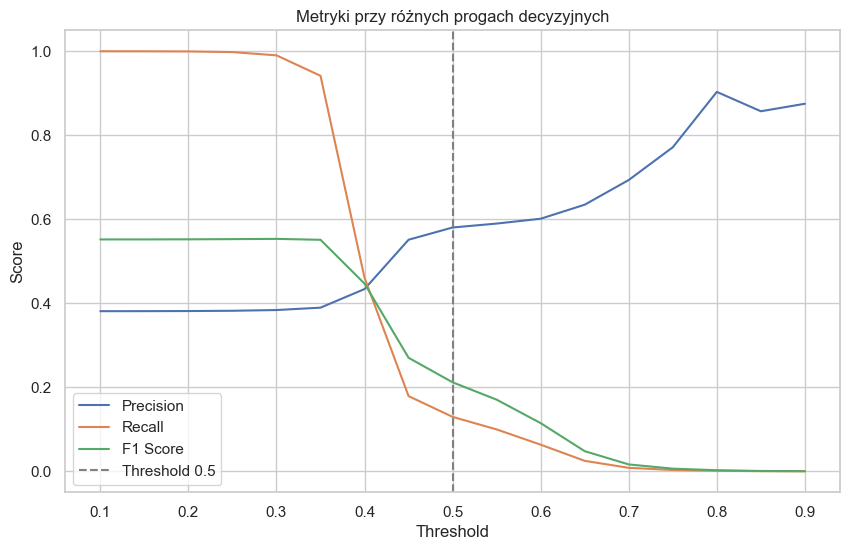

In [164]:
# 1. Pobieramy najlepszy model z GridSearchCV
model_best = grid_search.best_estimator_

# 2. Obliczamy prawdopodobieństwo dla klasy 1
y_proba = model_best.predict_proba(X_test)[:, 1]

# 3. Testujemy różne progi decyzyjne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)
precision_list = []
recall_list = []
f1_list = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    precision_list.append(precision_score(y_test, y_pred_thresh))
    recall_list.append(recall_score(y_test, y_pred_thresh))
    f1_list.append(f1_score(y_test, y_pred_thresh))

# 4. Rysujemy wykres
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1 Score')
plt.axvline(0.5, color='gray', linestyle='--', label='Threshold 0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metryki przy różnych progach decyzyjnych')
plt.legend()
plt.grid(True)
plt.show()


In [165]:
import pandas as pd

# Tworzymy DataFrame z wynikami
metrics_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-score': f1_list
})

# Zaokrąglamy dla czytelności
metrics_df = metrics_df.round(3)

# Wyświetlamy cały DataFrame
print(metrics_df)


    Threshold  Precision  Recall  F1-score
0        0.10      0.381   1.000     0.552
1        0.15      0.381   1.000     0.552
2        0.20      0.382   1.000     0.552
3        0.25      0.382   0.998     0.553
4        0.30      0.384   0.990     0.553
5        0.35      0.390   0.942     0.551
6        0.40      0.434   0.460     0.447
7        0.45      0.551   0.179     0.270
8        0.50      0.580   0.130     0.212
9        0.55      0.590   0.100     0.171
10       0.60      0.601   0.063     0.115
11       0.65      0.635   0.025     0.048
12       0.70      0.694   0.008     0.016
13       0.75      0.771   0.003     0.006
14       0.80      0.903   0.001     0.003
15       0.85      0.857   0.000     0.001
16       0.90      0.875   0.000     0.000


Mój wynik bardzo dobrze pokazuje klasyczny dylemat precision vs. recall w wykrywaniu rzadkich zdarzeń (tu: fraud).

| Threshold | Precision        | Recall                   | F1-score                  |
| --------- | ---------------- | ------------------------ | ------------------------- |
| 0.10–0.30 | \~0.38           | \~1.00                   | \~0.55 ← NAJLEPSZE F1     |
| 0.40+     | Precision rośnie | Recall spada drastycznie | F1 spada mocno            |


Najlepszy kompromis:

    Próg 0.25–0.30 daje najlepszy F1-score (0.553).

    W tym zakresie:

        Recall = ~0.99 → wykrywam prawie wszystkie fraudy.

        Precision = ~0.38 → mam sporo fałszywych alarmów, ale model jest czulszy.

PLAN :
1. Ustalić próg np. 0.30 i zastosować go w predykcjach końcowych:

In [166]:
# Próg decyzyjny
threshold = 0.30

# Predykcja z progiem
y_pred_thresh = (y_proba >= threshold).astype(int)

# Ocena
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))


[[ 1457 67626]
 [  415 42145]]
              precision    recall  f1-score   support

           0       0.78      0.02      0.04     69083
           1       0.38      0.99      0.55     42560

    accuracy                           0.39    111643
   macro avg       0.58      0.51      0.30    111643
weighted avg       0.63      0.39      0.24    111643



 wynik — jest bardzo interesujący i mówi nam sporo o zachowaniu modelu po zmianie progu na 0.30.

wyniki – interpretacja:

Macierz pomyłek:

TN: 1 457 ________   FP: 67 626

FN: 415  ________   TP: 42 145


| Klasa     | Precision | Recall                             | F1-score |
| --------- | --------- | ---------------------------------- | -------- |
| 0         | 0.78      | 0.02 → bardzo niskie!              | 0.04     |
| 1 (fraud) | 0.38      | 0.99 → prawie wszystko wykryte     | 0.55     |


Co to oznacza?

    Model wykrywa niemal wszystkie fraudy (recall 0.99) — to świetnie, jeśli ma być bardzo czuły na oszustwa.

    Ale robi to kosztem ogromnej liczby fałszywych alarmów (FP = 67 626).

    F1-score dla fraudów to 0.55 — najwyższy dotychczas!

    Jednak dla klasy 0 (brak fraudów), recall = 0.02, czyli praktycznie nie rozpoznaje ich.

PLAN:
znaleźć automatycznie najlepszy próg wg F1-score
poprzez zautomatyzowanie wyboru progu z najlepszym F1 

Szukam zatem teraz automatycznego najlepszego progu decyzyjnego, który maksymalizuje F1-score dla klasy 1 (fraud).

PLAN:

    Przeskanuję wiele progów (od 0.1 do 0.9).

    Dla każdego progu:

        Przekształcę prawdopodobieństwa na klasy (0 lub 1).

        Obliczę F1-score.

    Znajdę ten, który daje najwyższy F1-score.

In [167]:
import numpy as np
from sklearn.metrics import f1_score

# Zakładamy, że masz: model_best, X_test, y_test
# Krok 1: Prawdopodobieństwa klasy 1
y_proba = model_best.predict_proba(X_test)[:, 1]

# Krok 2: Szukanie najlepszego progu
thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

# Krok 3: Najlepszy próg i jego F1
best_index = np.argmax(f1_scores)
best_thresh = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"🔎 Najlepszy próg: {best_thresh:.2f} daje F1-score: {best_f1:.4f}")


🔎 Najlepszy próg: 0.31 daje F1-score: 0.5534


ANALIZA WYNIKU: 
próg decyzyjny 0.31 daje najlepszy balans między precyzją a czułością dla klasy 1 (fraud), według F1-score.

Co to oznacza?

Domyślnie klasyfikator używa progu 0.5, co często faworyzuje większościową klasę (czyli 0, brak fraudu). Obniżając próg do 0.31, pozwalam modelowi częściej klasyfikować na 1, co poprawia czułość (recall), kosztem nieco niższej precyzji.

1. Zastosuję ten próg i pokażę pełne metryki:

In [168]:
from sklearn.metrics import classification_report, confusion_matrix

# Klasyfikacja z najlepszym progiem
y_pred_best_thresh = (y_proba >= best_thresh).astype(int)

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_best_thresh)
print("📦 Macierz pomyłek:\n", cm)

# Raport klasyfikacji
print("\n📋 Raport klasyfikacji:\n")
print(classification_report(y_test, y_pred_best_thresh, digits=4))


📦 Macierz pomyłek:
 [[ 1902 67181]
 [  582 41978]]

📋 Raport klasyfikacji:

              precision    recall  f1-score   support

           0     0.7657    0.0275    0.0532     69083
           1     0.3846    0.9863    0.5534     42560

    accuracy                         0.3930    111643
   macro avg     0.5751    0.5069    0.3033    111643
weighted avg     0.6204    0.3930    0.2438    111643



 wynik świetnie pokazuje efekty zmiany progu decyzyjnego na 0.31.

co to oznacza :

| Metr                               | Interpretacja                         | Wynik przy progu 0.31                                                        |
| ---------------------------------- | ------------------------------------- | ---------------------------------------------------------------------------- |
| Recall (dla fraudów - klasa 1)     | % poprawnie wykrytych fraudów         |   98.63%   ✅ Bardzo wysoki – prawie wszystkie fraudy wykryte                              |
| Precision (dla fraudów)            | % trafień wśród wskazanych fraudów    |   38.46%   🔻 Nisko – wiele false positives                            |
| F1-score (dla fraudów)             | Zbalansowana miara precision i recall |   0.55   – najlepszy wśród testowanych progów                               |
| Accuracy                           | Ogólna trafność predykcji             |   39.3%   ❌ niska, bo wiele "zdrowych" (klasa 0) klasyfikowanych jako fraudy                          |


ANALIZA dotychczasowego wyniku modelu :

    mój model skutecznie znajduje fraudy (czyli ma bardzo dobrą czułość).

    Problemem jest precyzja – czyli zbyt wiele przypadków uznanych za fraudy nimi nie jest (false positives).

    Taki model może być dobry w systemie ostrzegania (alertowym), ale może być irytujący w automatycznych decyzjach (np. blokowanie płatności).